In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from benchutils.wandb_utils import get_runs
import numpy as np


In [8]:
COLUMN_NAMES = {
    "borf_": "BORF",
    "iborf_ridge_": "IBORF",
    'brits_': "BRITS",
    'dummy_': "NAIVE",
    'grud_': "GRU-D",
    'knn_dtw_': "KNN",
    'lgbm_': "LGBM",
    'rifc_': "RIFC",
    'rocket_': "ROCKET",
    'raindrop_': "RAINDROP",
    'svm_': "SVM",
    'ncde_': "NCDE"
}

COLUMNS_TO_DROP = [
    'lgbm_', 'rifc_', 'rocket_', "dummy_"
]

In [10]:
ROWS_TO_DROP = [
    # 'Abf',
 'Ais',
 'AllGestureWiimoteX',
 'AllGestureWiimoteY',
 'AllGestureWiimoteZ',
 # 'Animals',
 'AsphaltObstaclesCoordinates',
 'AsphaltPavementTypeCoordinates',
 'AsphaltRegularityCoordinates',
 'CharacterTrajectories',
 'CombinedTrajectories',
 # 'DodgerLoopDay',
 # 'DodgerLoopGame',
 # 'DodgerLoopWeekend',
 # 'Garment',
 # 'GeolifeSupervised',
 'GestureMidAirD1',
 'GestureMidAirD2',
 'GestureMidAirD3',
 'GesturePebbleZ1',
 'GesturePebbleZ2',
 'InsectWingbeat',
 'JapaneseVowels',
 # 'Ldfpa',
 'MelbournePedestrian',
 # 'Mimic3',
 'PLAID',
 # 'Pamap2',
 # 'Physionet2012',
 # 'Physionet2019',
 'PickupGestureWiimoteZ',
 # 'Seabirds',
 'ShakeGestureWiimoteZ',
 'SpokenArabicDigits',
 # 'Taxi',
 # 'Vehicles'
]

INDEX = ['Abf',
 # 'Ais',
 # 'AllGestureWiimoteX',
 # 'AllGestureWiimoteY',
 # 'AllGestureWiimoteZ',
 'Animals',
 # 'AsphaltObstaclesCoordinates',
 # 'AsphaltPavementTypeCoordinates',
 # 'AsphaltRegularityCoordinates',
 # 'CharacterTrajectories',
 # 'CombinedTrajectories',
 'DodgerLoopDay',
 'DodgerLoopGame',
 'DodgerLoopWeekend',
 'Garment',
 'GeolifeSupervised',
 # 'GestureMidAirD1',
 # 'GestureMidAirD2',
 # 'GestureMidAirD3',
 # 'GesturePebbleZ1',
 # 'GesturePebbleZ2',
 # 'InsectWingbeat',
 # 'JapaneseVowels',
 'Ldfpa',
 # 'MelbournePedestrian',
 'Mimic3',
 # 'PLAID',
 'Pamap2',
 'Physionet2012',
 'Physionet2019',
 # 'PickupGestureWiimoteZ',
 'Seabirds',
 # 'ShakeGestureWiimoteZ',
 # 'SpokenArabicDigits',
 'Taxi',
 'Vehicles']



In [6]:
",".join(INDEX)

'Abf,Animals,DodgerLoopDay,DodgerLoopGame,DodgerLoopWeekend,Garment,GeolifeSupervised,Ldfpa,Mimic3,Pamap2,Physionet2012,Physionet2019,Seabirds,Taxi,Vehicles'

In [11]:
def get_metric_df(
        df_orig,
        metric,
        nan_time=1440*60,
        fillna=True,
        drop_columns=None,
        drop_rows=None,
        aggfunc="mean",
        renamed_rows=None,
        renamed_columns=None,
):

    drop_rows = list() if drop_rows is None else drop_rows
    drop_columns = list() if drop_columns is None else drop_columns
    renamed_rows = dict() if renamed_rows is None else renamed_rows
    renamed_columns = dict() if renamed_columns is None else renamed_columns
    df = df_orig[["overrides.dataset", "model_str", metric]]
    df_metric = df.pivot_table(index='overrides.dataset', columns="model_str", values=metric, dropna=True, aggfunc=aggfunc)
    try:
        df_metric = df_metric.drop(drop_columns, axis=1)
        df_metric = df_metric.drop(drop_rows, axis=0)
    except:
        pass
    df_metric = df_metric.rename(renamed_columns, axis=1)
    df_metric = df_metric.rename(renamed_rows, axis=0)

    if fillna:
        if "time" in metric:
            df_metric = df_metric.fillna(nan_time)
        else:
            df_metric = df_metric.fillna(0)
    return df_metric

In [14]:
df_orig = get_runs("spinland", "iclm_01_time_not_channel")
DEFAULTS = dict()
model_columns = ["overrides.model"]
df_orig["model_str"] = ["" for _ in range(df_orig.shape[0])]
for column in model_columns:
    df_orig["model_str"] += df_orig[column].astype(str) + "_"

In [15]:
df_iborf = get_runs("fspinna", "iborf_classification")
model_columns = ["overrides.model"]
df_iborf["model_str"] = ["" for _ in range(df_iborf.shape[0])]
for column in model_columns:
    df_iborf["model_str"] += df_iborf[column].astype(str) + "_"

In [16]:
df_ = pd.concat([df_orig, df_iborf], axis=0)

In [17]:
get_metric_df(df_, "roc_auc")

model_str,borf_,borf_ridge_,brits_,dummy_,grud_,iborf_ridge_,knn_dtw_,lgbm_,ncde_,raindrop_,rifc_,rocket_,svm_
overrides.dataset,,,,,,,,,,,,,
Abf,0.500000,0.487278,0.494071,0.5,0.510914,0.978809,0.506484,0.500000,0.697973,0.498448,0.500000,0.500000,0.491667
Ais,0.810441,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AllGestureWiimoteX,0.887340,0.000000,0.627881,0.5,0.598623,0.000000,0.903582,0.848583,0.633701,0.812241,0.847806,0.937398,0.521429
AllGestureWiimoteY,0.918544,0.000000,0.701486,0.5,0.635367,0.000000,0.920680,0.884027,0.751926,0.827741,0.847289,0.945473,0.514286
AllGestureWiimoteZ,0.914982,0.000000,0.759378,0.5,0.605983,0.000000,0.901649,0.847814,0.576173,0.797918,0.829595,0.945824,0.505556
Animals,0.912279,0.918388,0.752160,0.5,0.747950,0.925823,0.916166,0.920034,0.654559,0.802791,0.966214,0.968945,0.316646
AsphaltObstaclesCoordinates,0.953437,0.000000,0.565452,0.5,0.723351,0.000000,0.865875,0.874375,0.808185,0.861390,0.895388,0.954682,0.355087
AsphaltPavementTypeCoordinates,0.982837,0.000000,0.907279,0.5,0.708147,0.000000,0.674577,0.938188,0.866604,0.917327,0.971877,0.994693,0.291540
AsphaltRegularityCoordinates,0.992232,0.000000,0.998446,0.5,0.689932,0.000000,0.567568,0.983684,0.869490,0.996407,0.811763,0.999792,0.104845


## CD PLOTS

In [18]:
from aeon.visualisation import plot_critical_difference, plot_significance, plot_pairwise_scatter, create_multi_comparison_matrix

In [19]:
metrics = {"f1": dict(),
           "accuracy": dict(),
           "precision": dict(),
           "recall": dict(),
           "roc_auc": dict(),
           "total_time": {"lower_better": True},
           "fit_time": {"lower_better": True},
           "predict_time": {"lower_better": True},
           }

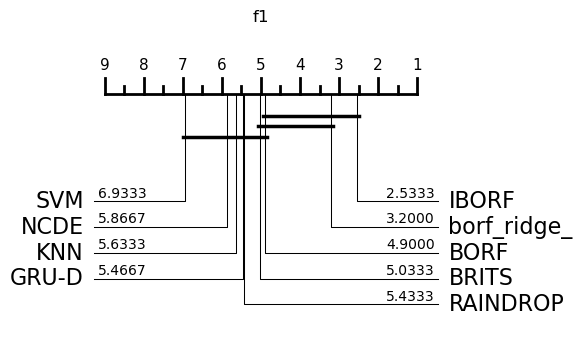

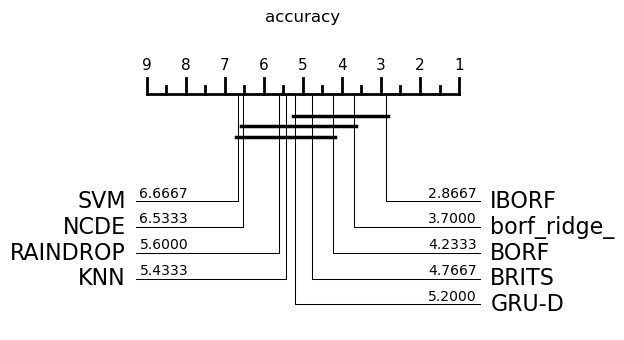

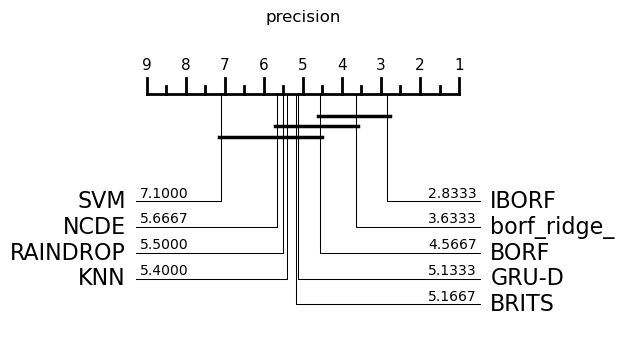

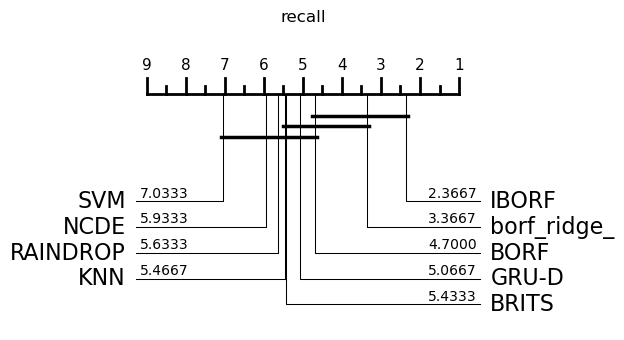

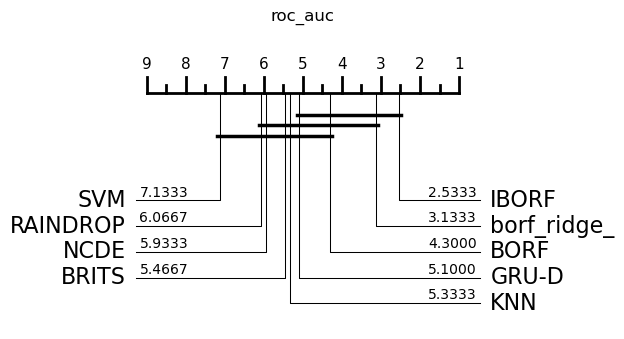

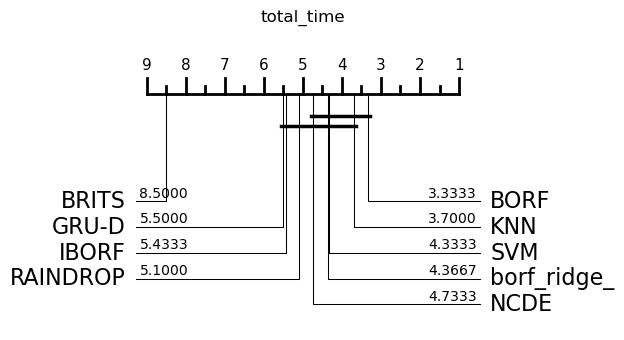

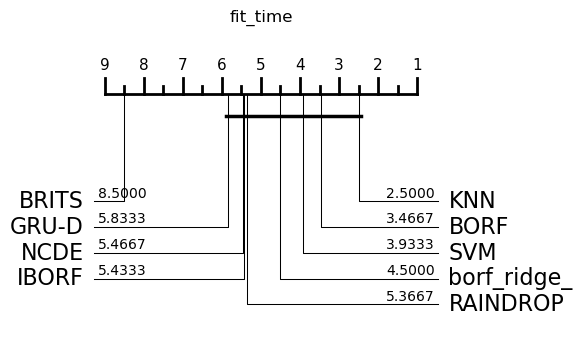

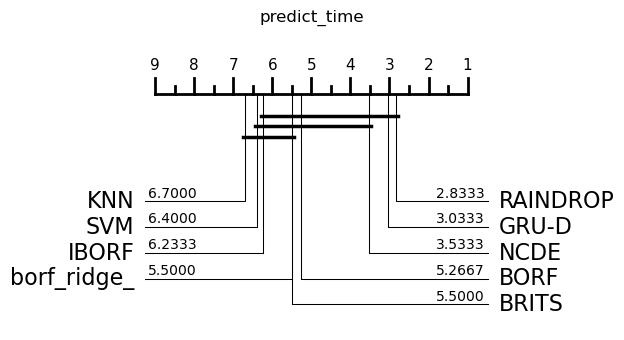

In [20]:
# sns.set_context("paper", font_scale=2)
for metric, kwargs in metrics.items():
    df_metric = get_metric_df(
        df_, metric, renamed_columns=COLUMN_NAMES, drop_rows=ROWS_TO_DROP, drop_columns=COLUMNS_TO_DROP
    )
    plt.style.use('default')
    fig, ax = plot_critical_difference(df_metric.values, labels=df_metric.columns, alpha=0.05, **kwargs)
    plt.title(metric)
    fig.set_size_inches(5, 3)
    plt.savefig(f"cd_plot_all_{metric}.pdf", dpi="figure", format="pdf", transparent=True, bbox_inches="tight")

## Table with STD

In [14]:
datasets = {
    "Abf": "ABF",
    "Animals": "AN",
    "GeolifeSupervised": "GS",
    "Seabirds": "SE",
    "Ldfpa": "LPA",
    "Mimic3": "MI3",
    "Pamap2": "PA2",
    "Physionet2012": "P12",
    "Physionet2019": "P19",
    "Taxi": "TA",
    "Vehicles": "VE",  # No abbreviation provided
    "Garment": "PGE",
    "AllGestureWiimoteX": "GX",
    "AllGestureWiimoteY": "GY",
    "AllGestureWiimoteZ": "GZ",
    "GestureMidAirD1": "GM1",
    "GestureMidAirD2": "GM2",
    "GestureMidAirD3": "GM3",
    "GesturePebbleZ1": "GP1",
    "GesturePebbleZ2": "GP2",
    "PickupGestureWiimoteZ": "PGZ",
    "ShakeGestureWiimoteZ": "SGZ",
    "PLAID": "PL",
    "DodgerLoopDay": "DD",
    "DodgerLoopGame": "DG",
    "DodgerLoopWeekend": "DW",
    "MelbournePedestrian": "MP",
    "AsphaltObstaclesCoordinates": "AOC",
    "AsphaltPavementTypeCoordinates": "APT",
    "AsphaltRegularityCoordinates": "ARC",
    "CharacterTrajectories": "CT",
    "InsectWingbeat": "IW",
    "JapaneseVowels": "JV",
    "SpokenArabicDigits": "SAD"
}
datasets = {key: "\\CDatasetAbbr{" + value + "}" for key, value in datasets.items()}


In [18]:
df_mean = get_metric_df(df_orig, metric="f1", fillna=False, aggfunc="mean")

In [42]:
df_std = get_metric_df(df_orig, metric="f1", fillna=True, aggfunc=np.nanstd)

/var/folders/kj/v66zvn217x31k6lx63lt02q40000gn/T/ipykernel_8324/1280079167.py:3: FutureWarning: The provided callable <function nanstd at 0x103b05c60> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_metric = df.pivot_table(index='overrides.dataset', columns="model_str", values=metric, dropna=True, aggfunc=aggfunc)


In [20]:
# df_std = get_metric_df(df_orig, metric="f1", fillna=False, aggfunc=np.nanstd)
# df_std

/var/folders/kj/v66zvn217x31k6lx63lt02q40000gn/T/ipykernel_8324/1280079167.py:3: FutureWarning: The provided callable <function nanstd at 0x103b05c60> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_metric = df.pivot_table(index='overrides.dataset', columns="model_str", values=metric, dropna=True, aggfunc=aggfunc)


model_str,BRITS,GRU-D,NCDE,RAINDROP,RIFC,ROCKET
overrides.dataset,,,,,,
Abf,0.008443,0.094360,0.023672,0.007097,0.000000,0.000000
AllGestureWiimoteX,0.085265,0.041702,0.051899,0.079060,0.114821,0.006079
AllGestureWiimoteY,0.070398,0.066150,0.006964,0.036326,0.137298,0.019944
AllGestureWiimoteZ,0.094653,0.040189,0.035123,0.036108,0.130371,0.009117
Animals,0.000000,0.031069,0.113326,0.054936,0.018103,0.035996
AsphaltObstaclesCoordinates,0.004079,0.275800,0.007693,0.027152,0.026047,0.008447
AsphaltPavementTypeCoordinates,0.017942,0.311926,0.004383,0.008714,0.027659,0.003332
AsphaltRegularityCoordinates,0.003766,0.095598,0.003366,0.008027,0.280315,0.005041
CharacterTrajectories,0.045337,0.304167,0.014339,0.004172,0.022223,0.003187


In [43]:
df_std = get_metric_df(df_orig, metric="f1", fillna=True, aggfunc="std")
df_std

model_str,BRITS,GRU-D,NCDE,RAINDROP,RIFC,ROCKET
overrides.dataset,,,,,,
Abf,0.008443,0.094360,0.023672,0.007097,0.000000,0.000000
AllGestureWiimoteX,0.085265,0.041702,0.051899,0.079060,0.114821,0.006079
AllGestureWiimoteY,0.070398,0.066150,0.006964,0.036326,0.137298,0.019944
AllGestureWiimoteZ,0.094653,0.040189,0.035123,0.036108,0.130371,0.009117
Animals,0.000000,0.031069,0.113326,0.054936,0.018103,0.035996
AsphaltObstaclesCoordinates,0.004079,0.275800,0.007693,0.027152,0.026047,0.008447
AsphaltPavementTypeCoordinates,0.017942,0.311926,0.004383,0.008714,0.027659,0.003332
AsphaltRegularityCoordinates,0.003766,0.095598,0.003366,0.008027,0.280315,0.005041
CharacterTrajectories,0.045337,0.304167,0.014339,0.004172,0.022223,0.003187


In [45]:
latex_table = df_mean.copy()

for column in df_mean.columns:
    if column in df_std.columns:
        latex_table[column] = df_mean[column].apply(
            lambda x: f"{x:.2f}" if pd.notnull(x) else "-"
        ) + " \\scriptsize{$\\pm$ " + df_std[column].apply(
            lambda x: f"{x:.2f}" if pd.notnull(x) else "-"
        ) + "}"
    else:
        latex_table[column] = df_mean[column].apply(
            lambda x: f"{x:.2f}" if pd.notnull(x) else "-"
        )

# Bold the best mean value in each row (only the mean)
for idx, row in df_mean.iterrows():
    max_val = row.max()
    for col in df_mean.columns:
        if pd.notnull(row[col]) and row[col] == max_val:
            if col in df_std.columns:
                std_value = df_std.at[idx, col]
                latex_table.at[idx, col] = f"\\textbf{{{row[col]:.2f}}} \\scriptsize{{$\\pm$ {std_value:.2f}}}"
            else:
                latex_table.at[idx, col] = f"\\textbf{{{row[col]:.2f}}}"

# Replace NaN means with '-' (without std)
for idx, row in latex_table.iterrows():
    for col in df_mean.columns:
        if pd.isnull(df_mean.at[idx, col]):  # Check for NaN
            latex_table.at[idx, col] = "-"

columns = ["\\CMethod{" + i.lower() + "}" for i in latex_table.columns]
latex_table = latex_table.rename(datasets, axis=0)
latex_table = latex_table.sort_index(axis=0)
latex_table.columns = columns


In [23]:
latex_table

,\CMethod{borf},\CMethod{brits},\CMethod{gru-d},\CMethod{knn},\CMethod{lgbm},\CMethod{ncde},\CMethod{raindrop},\CMethod{rifc},\CMethod{rocket},\CMethod{svm}
overrides.dataset,,,,,,,,,,
\CDatasetAbbr{ABF},0.17,0.33 \scriptsize{$\pm$ 0.01},0.28 \scriptsize{$\pm$ 0.09},0.31,0.17,\textbf{0.41} \scriptsize{$\pm$ 0.02},0.27 \scriptsize{$\pm$ 0.01},0.17 \scriptsize{$\pm$ 0.00},0.17 \scriptsize{$\pm$ 0.00},0.32
\CDatasetAbbr{AN},0.80,0.65 \scriptsize{$\pm$ 0.00},0.68 \scriptsize{$\pm$ 0.03},0.80,0.80,0.43 \scriptsize{$\pm$ 0.11},0.64 \scriptsize{$\pm$ 0.05},0.88 \scriptsize{$\pm$ 0.02},\textbf{0.90} \scriptsize{$\pm$ 0.04},0.07
\CDatasetAbbr{AOC},\textbf{0.82},0.30 \scriptsize{$\pm$ 0.00},0.31 \scriptsize{$\pm$ 0.28},0.64,0.68,0.51 \scriptsize{$\pm$ 0.01},0.66 \scriptsize{$\pm$ 0.03},0.68 \scriptsize{$\pm$ 0.03},0.80 \scriptsize{$\pm$ 0.01},0.02
\CDatasetAbbr{APT},0.91,0.78 \scriptsize{$\pm$ 0.02},0.49 \scriptsize{$\pm$ 0.31},0.34,0.80,0.69 \scriptsize{$\pm$ 0.00},0.77 \scriptsize{$\pm$ 0.01},0.88 \scriptsize{$\pm$ 0.03},\textbf{0.96} \scriptsize{$\pm$ 0.00},0.05
\CDatasetAbbr{ARC},0.95,0.99 \scriptsize{$\pm$ 0.00},0.63 \scriptsize{$\pm$ 0.10},0.36,0.95,0.81 \scriptsize{$\pm$ 0.00},0.97 \scriptsize{$\pm$ 0.01},0.77 \scriptsize{$\pm$ 0.28},\textbf{0.99} \scriptsize{$\pm$ 0.01},0.10
\CDatasetAbbr{CT},0.94,0.96 \scriptsize{$\pm$ 0.05},0.64 \scriptsize{$\pm$ 0.30},\textbf{0.98},0.95,0.87 \scriptsize{$\pm$ 0.01},0.97 \scriptsize{$\pm$ 0.00},0.94 \scriptsize{$\pm$ 0.02},0.98 \scriptsize{$\pm$ 0.00},0.68
\CDatasetAbbr{DD},0.51,0.52 \scriptsize{$\pm$ 0.02},0.46 \scriptsize{$\pm$ 0.07},0.44,0.52,0.29 \scriptsize{$\pm$ 0.12},0.45 \scriptsize{$\pm$ 0.04},0.49 \scriptsize{$\pm$ 0.04},\textbf{0.54} \scriptsize{$\pm$ 0.03},0.23
\CDatasetAbbr{DG},0.34,0.72 \scriptsize{$\pm$ 0.07},0.71 \scriptsize{$\pm$ 0.07},\textbf{0.90},0.34,0.51 \scriptsize{$\pm$ 0.04},0.60 \scriptsize{$\pm$ 0.22},0.34 \scriptsize{$\pm$ 0.00},0.34 \scriptsize{$\pm$ 0.00},0.85
\CDatasetAbbr{DW},0.42,0.93 \scriptsize{$\pm$ 0.02},0.63 \scriptsize{$\pm$ 0.27},\textbf{0.97},0.42,0.80 \scriptsize{$\pm$ 0.13},0.78 \scriptsize{$\pm$ 0.31},0.42 \scriptsize{$\pm$ 0.00},0.42 \scriptsize{$\pm$ 0.00},0.96


In [46]:
print(
    latex_table.to_latex(
        na_rep="{-}",
        caption="F1 score on the test set for each dataset and each classifier. Missing values are due to exceeded memory or maximum runtime.",
        escape=False
    )
)

\begin{table}
\caption{F1 score on the test set for each dataset and each classifier. Missing values are due to exceeded memory or maximum runtime.}
\begin{tabular}{lllllllllll}
\toprule
 & \CMethod{borf} & \CMethod{brits} & \CMethod{gru-d} & \CMethod{knn} & \CMethod{lgbm} & \CMethod{ncde} & \CMethod{raindrop} & \CMethod{rifc} & \CMethod{rocket} & \CMethod{svm} \\
overrides.dataset &  &  &  &  &  &  &  &  &  &  \\
\midrule
\CDatasetAbbr{ABF} & 0.17 & 0.33 \scriptsize{$\pm$ 0.01} & 0.28 \scriptsize{$\pm$ 0.09} & 0.31 & 0.17 & \textbf{0.41} \scriptsize{$\pm$ 0.02} & 0.27 \scriptsize{$\pm$ 0.01} & 0.17 \scriptsize{$\pm$ 0.00} & 0.17 \scriptsize{$\pm$ 0.00} & 0.32 \\
\CDatasetAbbr{AN} & 0.80 & 0.65 \scriptsize{$\pm$ 0.00} & 0.68 \scriptsize{$\pm$ 0.03} & 0.80 & 0.80 & 0.43 \scriptsize{$\pm$ 0.11} & 0.64 \scriptsize{$\pm$ 0.05} & 0.88 \scriptsize{$\pm$ 0.02} & \textbf{0.90} \scriptsize{$\pm$ 0.04} & 0.07 \\
\CDatasetAbbr{AOC} & \textbf{0.82} & 0.30 \scriptsize{$\pm$ 0.00} & 0.31 \scriptsize

In [25]:
latex_table

,\CMethod{borf},\CMethod{brits},\CMethod{gru-d},\CMethod{knn},\CMethod{lgbm},\CMethod{ncde},\CMethod{raindrop},\CMethod{rifc},\CMethod{rocket},\CMethod{svm}
overrides.dataset,,,,,,,,,,
\CDatasetAbbr{ABF},0.17,0.33 \scriptsize{$\pm$ 0.01},0.28 \scriptsize{$\pm$ 0.09},0.31,0.17,\textbf{0.41} \scriptsize{$\pm$ 0.02},0.27 \scriptsize{$\pm$ 0.01},0.17 \scriptsize{$\pm$ 0.00},0.17 \scriptsize{$\pm$ 0.00},0.32
\CDatasetAbbr{AN},0.80,0.65 \scriptsize{$\pm$ 0.00},0.68 \scriptsize{$\pm$ 0.03},0.80,0.80,0.43 \scriptsize{$\pm$ 0.11},0.64 \scriptsize{$\pm$ 0.05},0.88 \scriptsize{$\pm$ 0.02},\textbf{0.90} \scriptsize{$\pm$ 0.04},0.07
\CDatasetAbbr{AOC},\textbf{0.82},0.30 \scriptsize{$\pm$ 0.00},0.31 \scriptsize{$\pm$ 0.28},0.64,0.68,0.51 \scriptsize{$\pm$ 0.01},0.66 \scriptsize{$\pm$ 0.03},0.68 \scriptsize{$\pm$ 0.03},0.80 \scriptsize{$\pm$ 0.01},0.02
\CDatasetAbbr{APT},0.91,0.78 \scriptsize{$\pm$ 0.02},0.49 \scriptsize{$\pm$ 0.31},0.34,0.80,0.69 \scriptsize{$\pm$ 0.00},0.77 \scriptsize{$\pm$ 0.01},0.88 \scriptsize{$\pm$ 0.03},\textbf{0.96} \scriptsize{$\pm$ 0.00},0.05
\CDatasetAbbr{ARC},0.95,0.99 \scriptsize{$\pm$ 0.00},0.63 \scriptsize{$\pm$ 0.10},0.36,0.95,0.81 \scriptsize{$\pm$ 0.00},0.97 \scriptsize{$\pm$ 0.01},0.77 \scriptsize{$\pm$ 0.28},\textbf{0.99} \scriptsize{$\pm$ 0.01},0.10
\CDatasetAbbr{CT},0.94,0.96 \scriptsize{$\pm$ 0.05},0.64 \scriptsize{$\pm$ 0.30},\textbf{0.98},0.95,0.87 \scriptsize{$\pm$ 0.01},0.97 \scriptsize{$\pm$ 0.00},0.94 \scriptsize{$\pm$ 0.02},0.98 \scriptsize{$\pm$ 0.00},0.68
\CDatasetAbbr{DD},0.51,0.52 \scriptsize{$\pm$ 0.02},0.46 \scriptsize{$\pm$ 0.07},0.44,0.52,0.29 \scriptsize{$\pm$ 0.12},0.45 \scriptsize{$\pm$ 0.04},0.49 \scriptsize{$\pm$ 0.04},\textbf{0.54} \scriptsize{$\pm$ 0.03},0.23
\CDatasetAbbr{DG},0.34,0.72 \scriptsize{$\pm$ 0.07},0.71 \scriptsize{$\pm$ 0.07},\textbf{0.90},0.34,0.51 \scriptsize{$\pm$ 0.04},0.60 \scriptsize{$\pm$ 0.22},0.34 \scriptsize{$\pm$ 0.00},0.34 \scriptsize{$\pm$ 0.00},0.85
\CDatasetAbbr{DW},0.42,0.93 \scriptsize{$\pm$ 0.02},0.63 \scriptsize{$\pm$ 0.27},\textbf{0.97},0.42,0.80 \scriptsize{$\pm$ 0.13},0.78 \scriptsize{$\pm$ 0.31},0.42 \scriptsize{$\pm$ 0.00},0.42 \scriptsize{$\pm$ 0.00},0.96


## Multiple Comparison Matrix

In [59]:
metrics = {"f1": dict(),
           "accuracy": dict(),
           "total_time": {"order_better": "increasing"},
           "fit_time": {"order_better": "increasing"},
           "predict_time": {"order_better": "increasing"},
           }

In [60]:
for metric, kwargs in metrics.items():
    df_metric = get_metric_df(
        df_, metric, renamed_columns=COLUMN_NAMES, drop_rows=ROWS_TO_DROP, drop_columns=COLUMNS_TO_DROP
    )
    create_multi_comparison_matrix(
        df_metric,
        fig_size=(13,4.5),
        font_size=8,
        pdf_savename=f"mcm_all_{metric}",
        tex_savename=f"mcm_all_{metric}",
        csv_savename=f"mcm_all_{metric}",
        used_statistic=metric,
        show_symetry=True,
        precision=3,
        colorbar_orientation="vertical",
        pvalue_threshold=0.05,
        # colormap=None,
        **kwargs
    )

## Perf vs Time

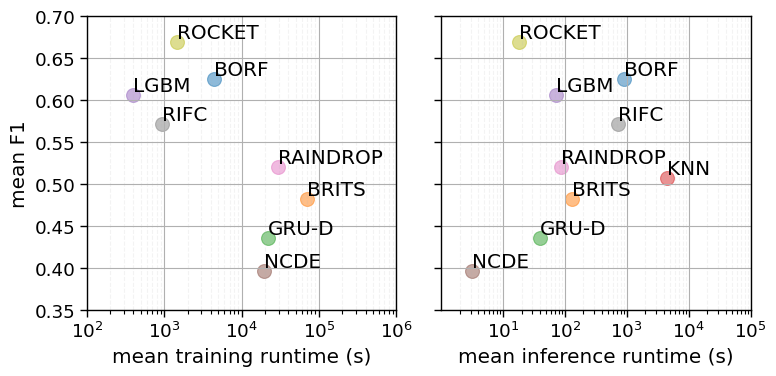

In [34]:
df_metric = get_metric_df(df_orig, metric="f1")
df_time_fit = get_metric_df(df_orig, metric="fit_time", nan_time=5000 * 60, fillna=True)
df_time_predict = get_metric_df(df_orig, metric="predict_time", nan_time = 5000 * 30, fillna=False)

df_time_fit_med = df_time_fit.mean()
df_time_predict_med = df_time_predict.mean()
df_metric_med = df_metric.fillna(0).mean()
df_metric_med.fillna(0).mean()

minor_grid_alpha = 0.15

plt.style.use('default')
sns.set_context("paper", font_scale=1.5)
SIZE = 100

fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)

ax0 = axs[0]
ax1 = axs[1]

colors = [f"C{i}" for i in range(20)]

for i, model in enumerate(df_metric_med.index):
    if model in ["SVM", "KNN"]:
        continue
    ax0.scatter(df_time_fit_med[model], df_metric_med[model], alpha=0.5, s=SIZE, c=colors[i])
    ax0.text(df_time_fit_med[model], df_metric_med[model], model, ha='left', va='bottom')

ax0.set_xscale("log")
ax0.grid(True, which='major')  #, color='b', linestyle='-')
ax0.grid(True, which='minor', alpha=minor_grid_alpha, linestyle='--')
ax0.set_ylim(0.44, 0.7)
ax0.set_xlim(1e2, 1e6)

ax0.set_ylabel("mean F1")
ax0.set_xlabel("mean training runtime (s)")


for i, model in enumerate(df_metric_med.index):
    if model in ["SVM"]:
        continue
    ax1.scatter(df_time_predict_med[model], df_metric_med[model], alpha=0.5, s=SIZE, c=colors[i])
    ax1.text(df_time_predict_med[model], df_metric_med[model], model, ha='left', va='bottom')

ax1.set_xscale("log")
ax1.grid(True, which='major')  #, color='b', linestyle='-')
ax1.grid(True, which='minor', alpha=minor_grid_alpha, linestyle='--')
ax1.set_ylim(0.35, 0.7)
ax1.set_xlim(1e0+0.001, 1e5)
ax1.set_xlabel("mean inference runtime (s)")

plt.tight_layout()

plt.savefig(f"f1_vs_fit_predict.pdf", dpi="figure", format="pdf", transparent=True, bbox_inches="tight")

## Pairwise Comparison

In [35]:
df_metric = get_metric_df(df_orig, metric="f1")

In [36]:
method_a = "RAINDROP"
method_b = "ROCKET"
method_c = "NCDE"

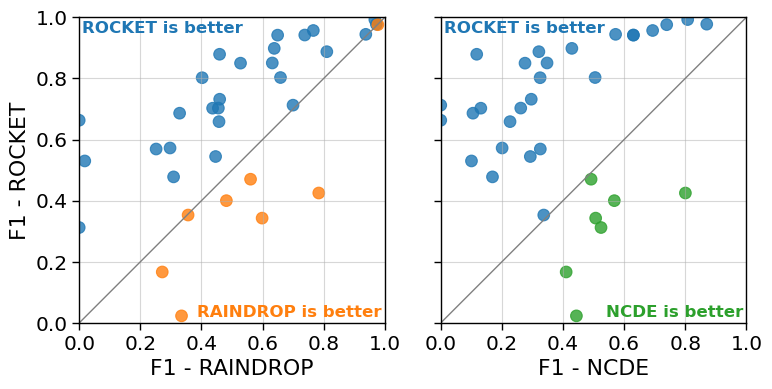

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

method_a = "RAINDROP"
method_b = "ROCKET"
method_c = "NCDE"

plt.style.use('default')
sns.set_context("paper", font_scale=1.65)
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)

minor_grid_alpha = 0.15

SIZE = 70

# Prepare data
x_a_b = df_metric.fillna(0)[method_a].values
y_a_b = df_metric.fillna(0)[method_b].values

x_c_b = df_metric.fillna(0)[method_c].values
y_c_b = df_metric.fillna(0)[method_b].values

# Calculate medians
median_x_a_b = np.median(x_a_b)
median_y_a_b = np.median(y_a_b)

median_x_c_b = np.median(x_c_b)
median_y_c_b = np.median(y_c_b)

# Determine colors for points based on their position relative to the bisecting line
colors_a_b = np.where(y_a_b > x_a_b, 'C0', 'C1')  # Above line: 'C0', Below line: 'C1'
colors_c_b = np.where(y_c_b > x_c_b, 'C0', 'C2')

# Scatter plot for ax0
ax0 = axs[0]

ax0.scatter(x_a_b, y_a_b, c=colors_a_b, s=SIZE, alpha=0.8)

# Set limits and aspect ratio
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.set_xlabel("F1 - RAINDROP")
ax0.set_ylabel("F1 - ROCKET")
ax0.set_aspect('equal', adjustable='box')
ax0.plot([0, 1], [0, 1], 'gray', linewidth=1)  # Add bisecting line

# Add median lines for ax0
# ax0.plot([median_x_a_b, median_x_a_b], [0, median_x_a_b], 'C1', linewidth=1.5, linestyle="--")  # Vertical line
# ax0.plot([0, median_y_a_b], [median_y_a_b, median_y_a_b], 'C0', linewidth=1.5, linestyle="--")  # Horizontal line

# Add text annotations
ax0.text(0.01, 0.99, "ROCKET is better", transform=ax0.transAxes, fontsize=12, va='top', ha='left', color="C0", weight='bold')
ax0.text(0.99, 0.01, "RAINDROP is better", transform=ax0.transAxes, fontsize=12, va='bottom', ha='right', color="C1", weight='bold')

ax0.grid(True, which='major', alpha=0.5)

# Scatter plot for ax1
ax1 = axs[1]
ax1.scatter(x_c_b, y_c_b, c=colors_c_b, s=SIZE, alpha=0.8)

# Set limits and aspect ratio
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_xlabel("F1 - NCDE")
ax1.set_aspect('equal', adjustable='box')
ax1.plot([0, 1], [0, 1], 'gray', linewidth=1)  # Add bisecting line
ax1.set_xticks(np.arange(0.0, 1.01, 0.2))

# Add median lines for ax1
# ax1.plot([median_x_c_b, median_x_c_b], [0, median_x_c_b], 'C2', linewidth=1.5, linestyle="--")  # Vertical line
# ax1.plot([0, median_y_c_b], [median_y_c_b, median_y_c_b], 'C0', linewidth=1.5, linestyle="--")  # Horizontal line

# Add text annotations
ax1.text(0.01, 0.99, "ROCKET is better", transform=ax1.transAxes, fontsize=12, va='top', ha='left', color="C0", weight='bold')
ax1.text(0.99, 0.01, "NCDE is better", transform=ax1.transAxes, fontsize=12, va='bottom', ha='right', color="C2", weight='bold')

ax1.grid(True, which='major', alpha=0.5)

plt.tight_layout()
plt.savefig(f"pairwise_comparison.pdf", dpi="figure", format="pdf", transparent=True, bbox_inches="tight")


(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='ROCKET F1\n(mean: 0.3958)', ylabel='RAINDROP F1\n(mean: 0.6689)'>)

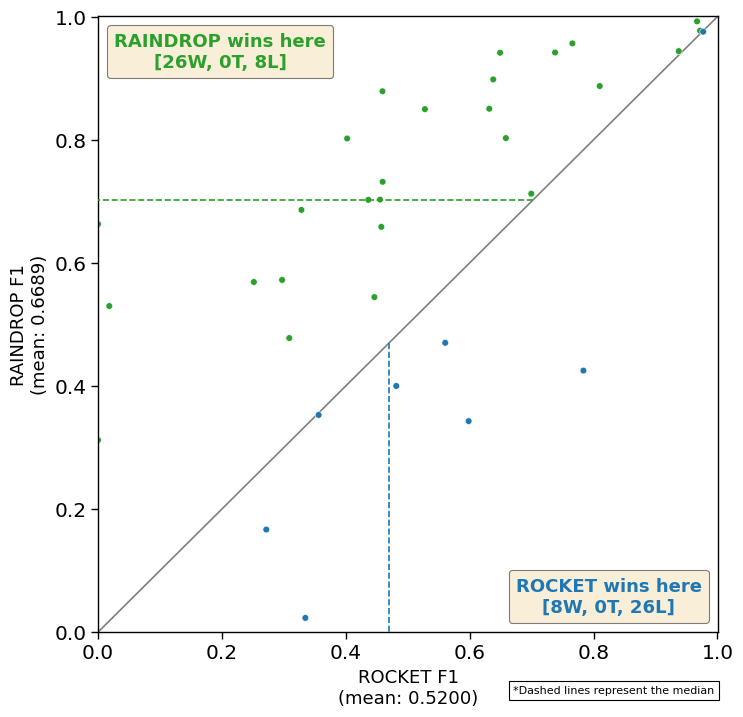

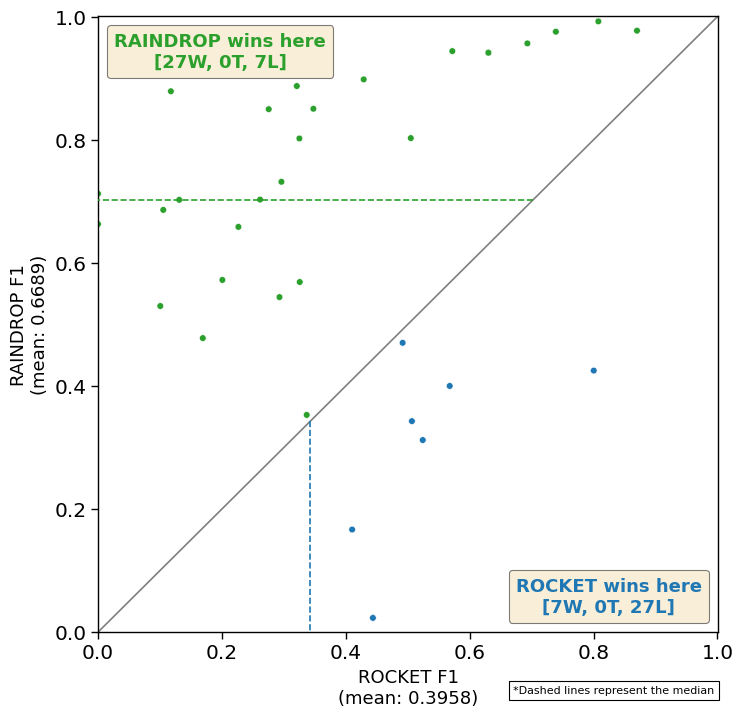

In [38]:
method_a = "RAINDROP"
method_b = "ROCKET"
method_c = "NCDE"

plot_pairwise_scatter(
    df_metric.fillna(0)[method_b].values,
    df_metric.fillna(0)[method_a].values,
    method_a=method_a,
    method_b=method_b,
    figsize=(8,8),
    metric="F1",
    statistic_tests=False
)
plot_pairwise_scatter(
    df_metric.fillna(0)[method_b].values,
    df_metric.fillna(0)[method_c].values,
    method_a=method_a,
    method_b=method_b,
    figsize=(8,8),
    metric="F1",
    statistic_tests=False
)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/aeon/visualisation/results/_scatter.py:105: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize, gridspec_kw=dict(bottom=0.2))


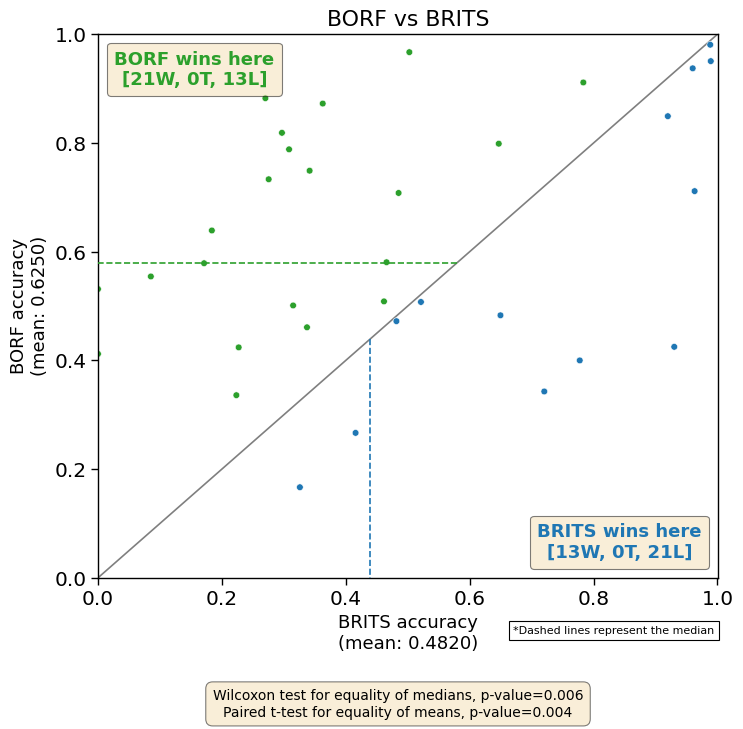

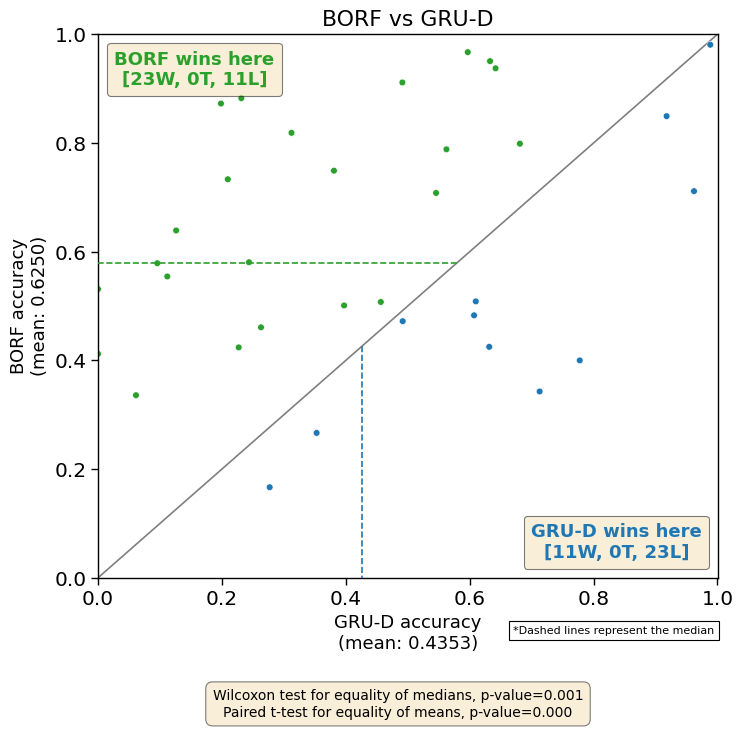

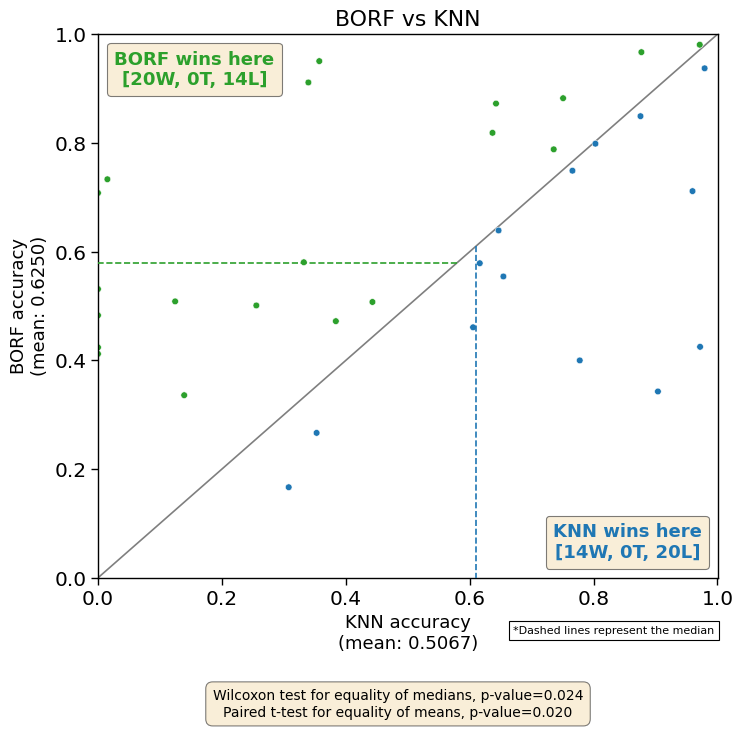

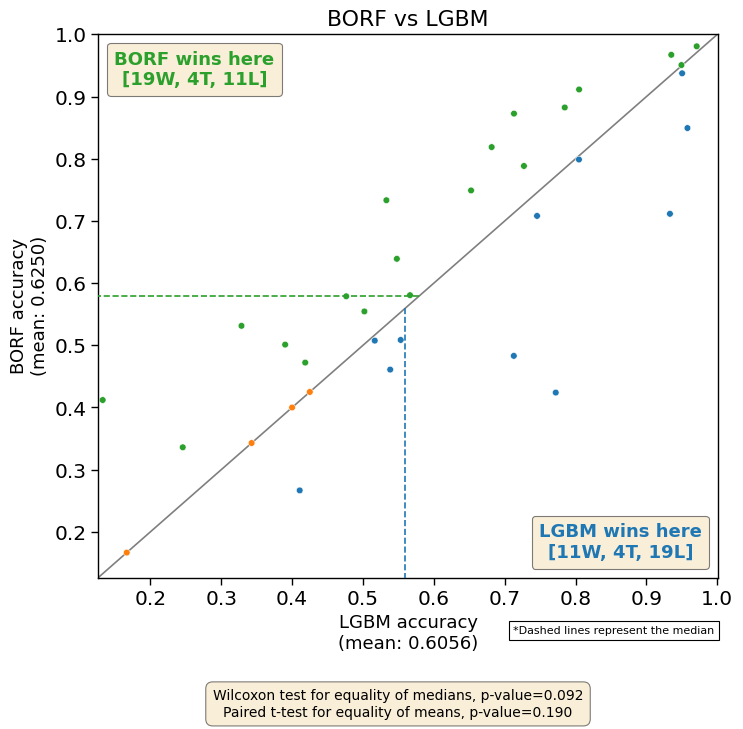

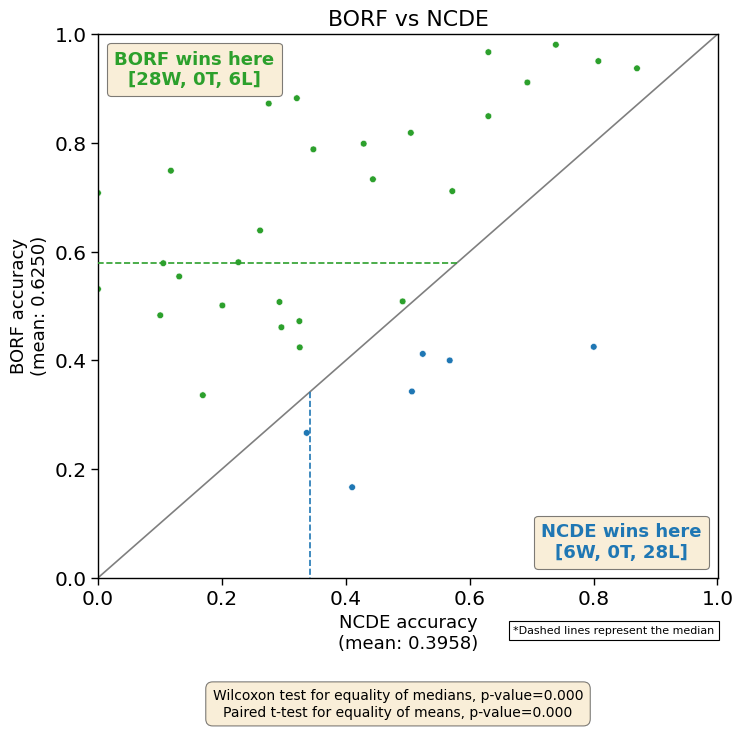

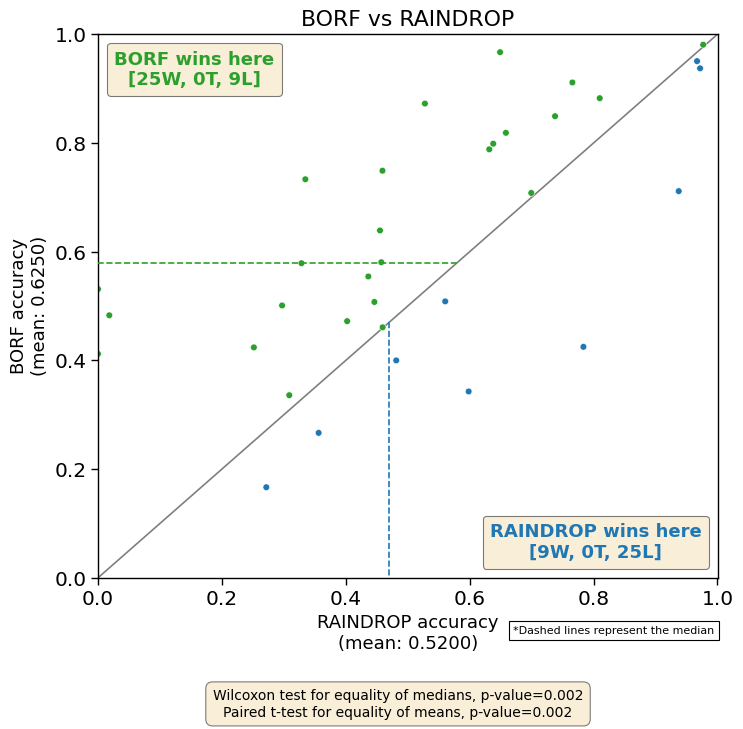

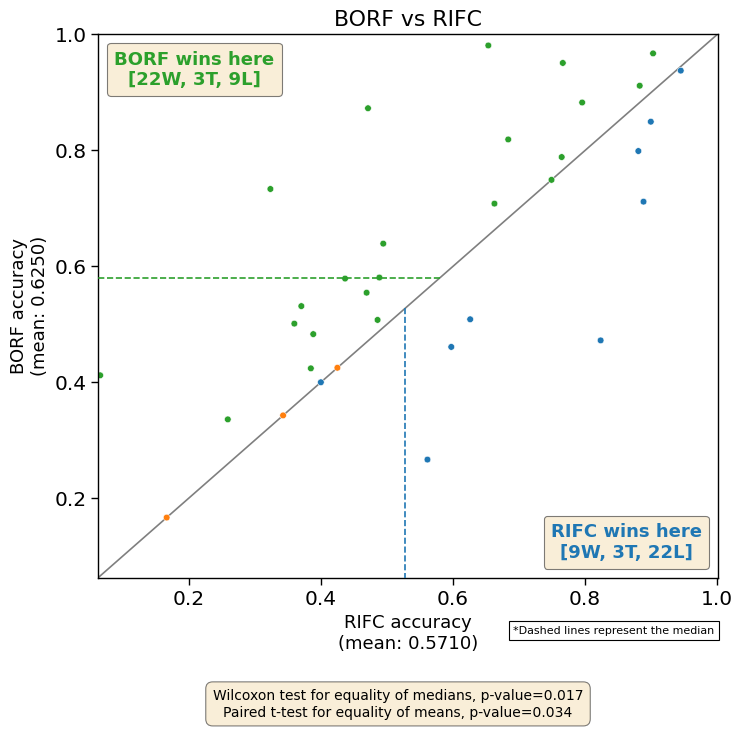

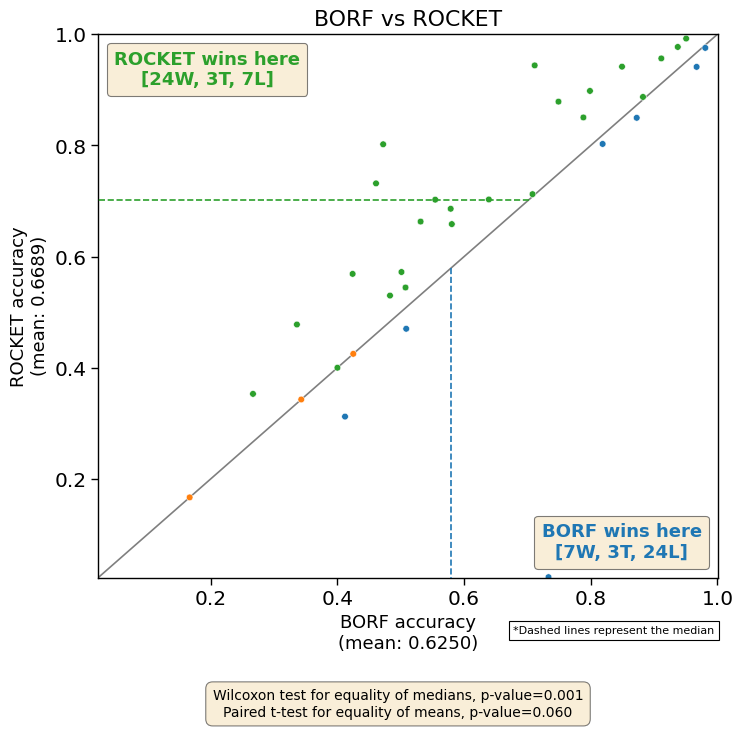

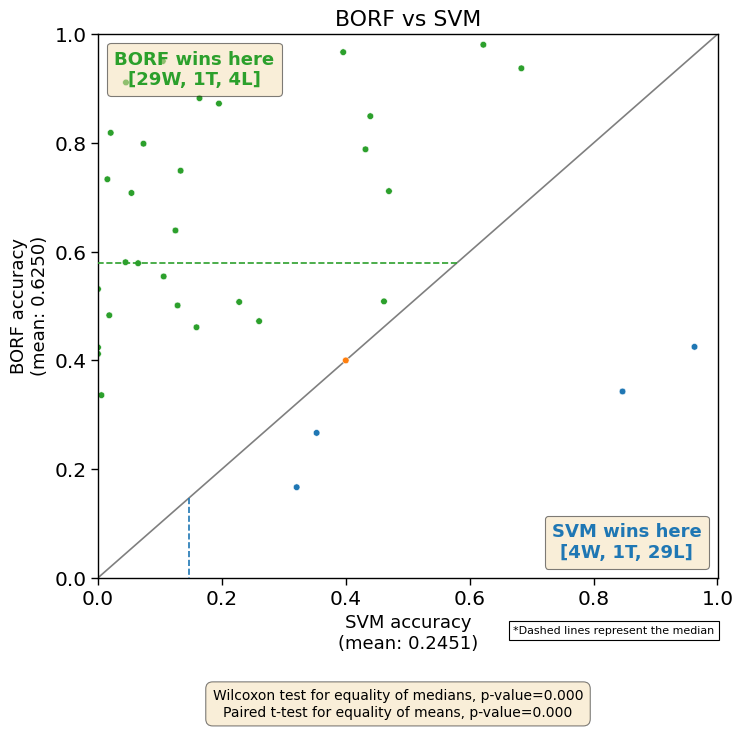

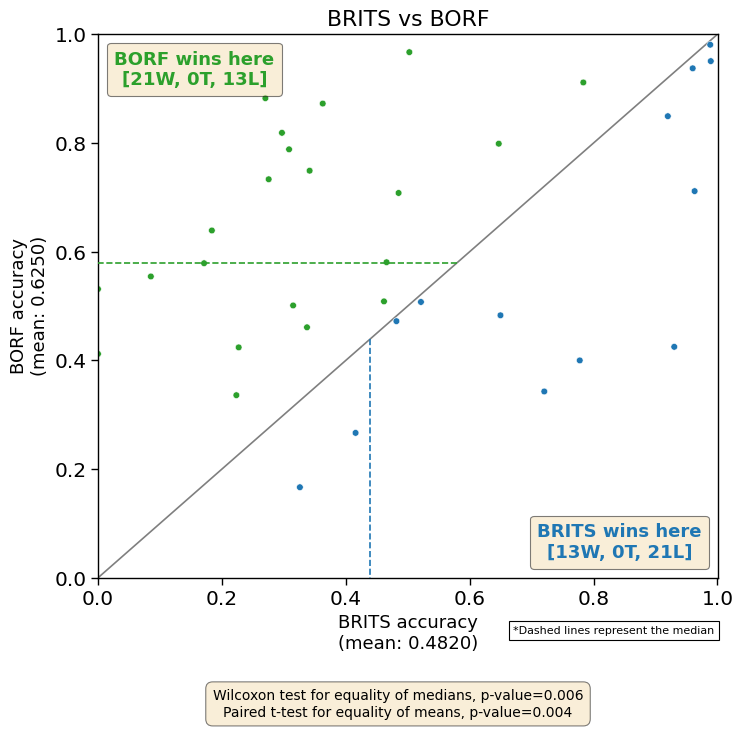

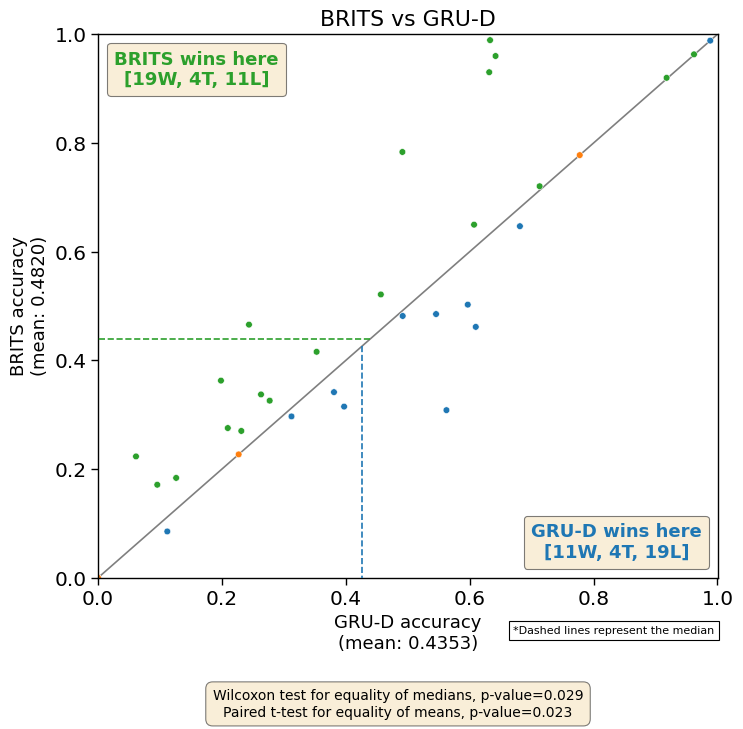

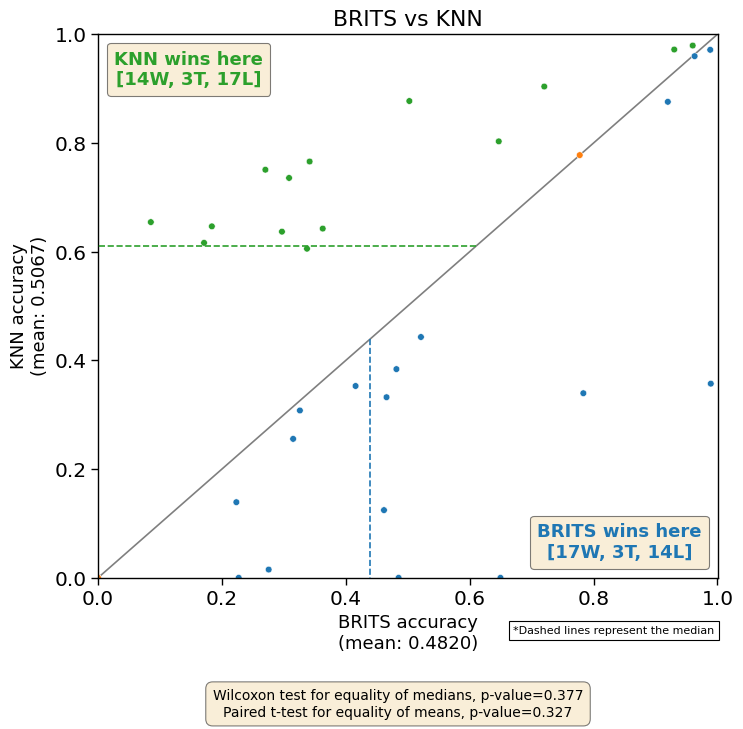

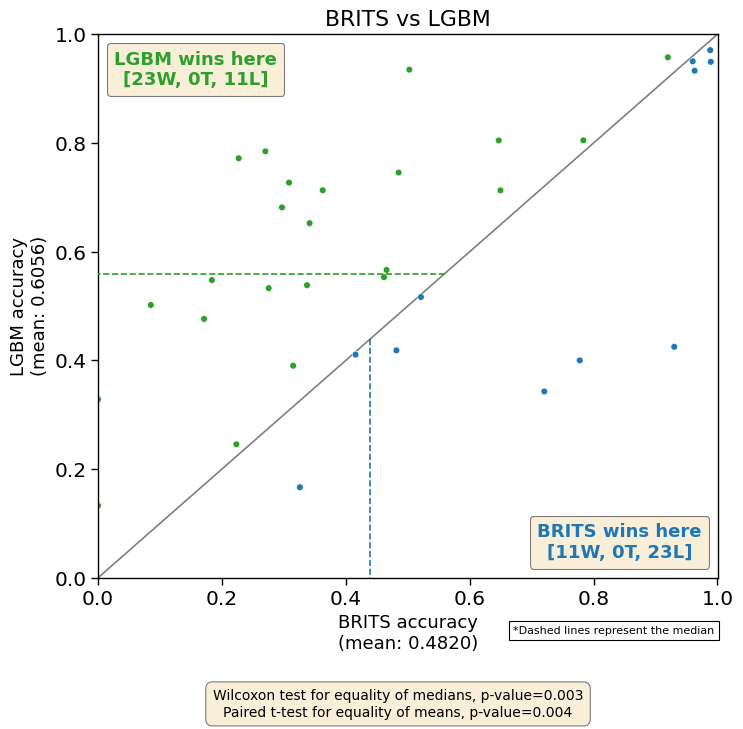

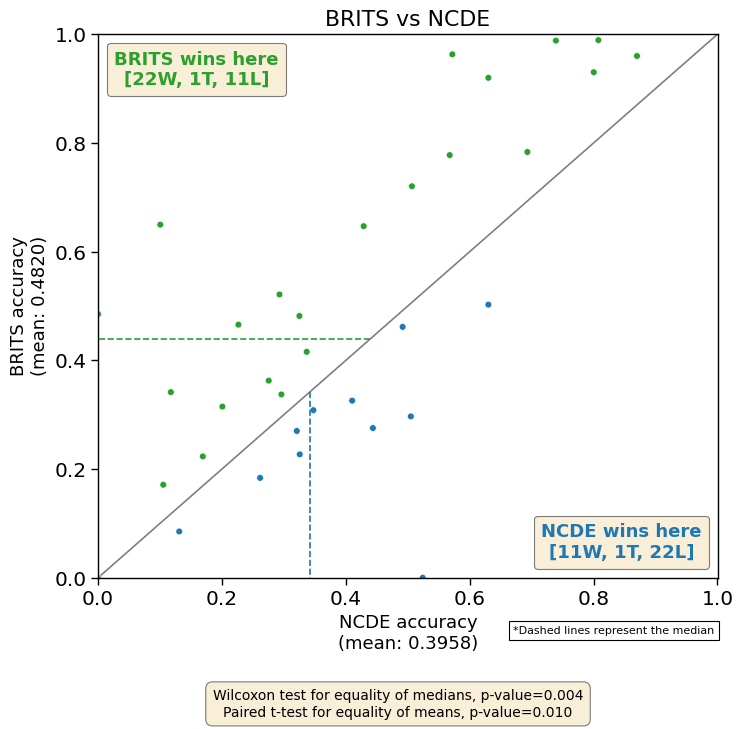

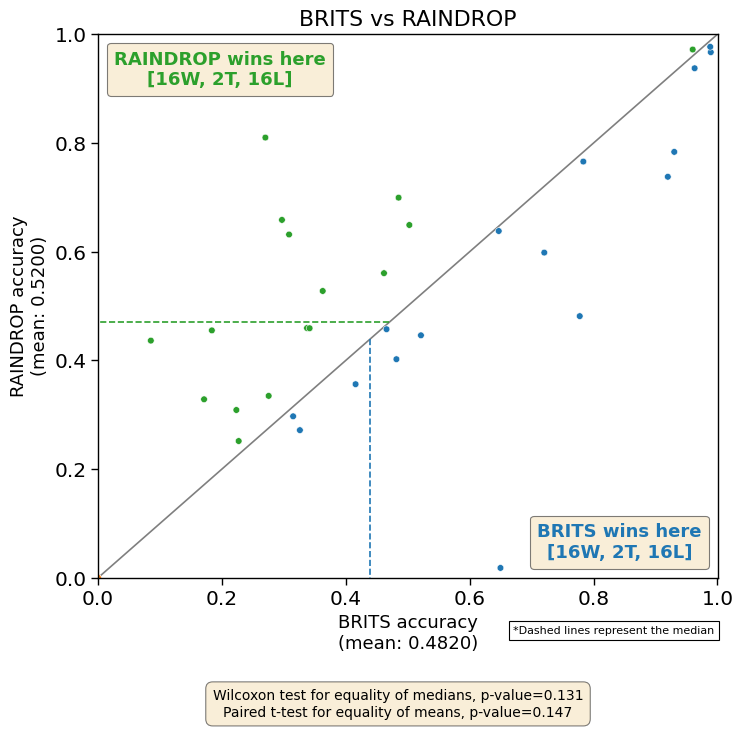

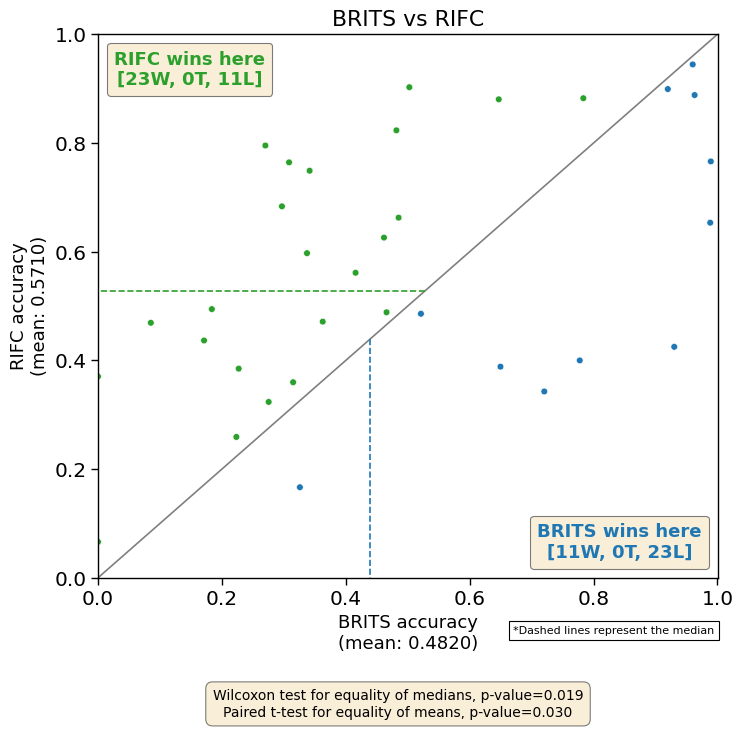

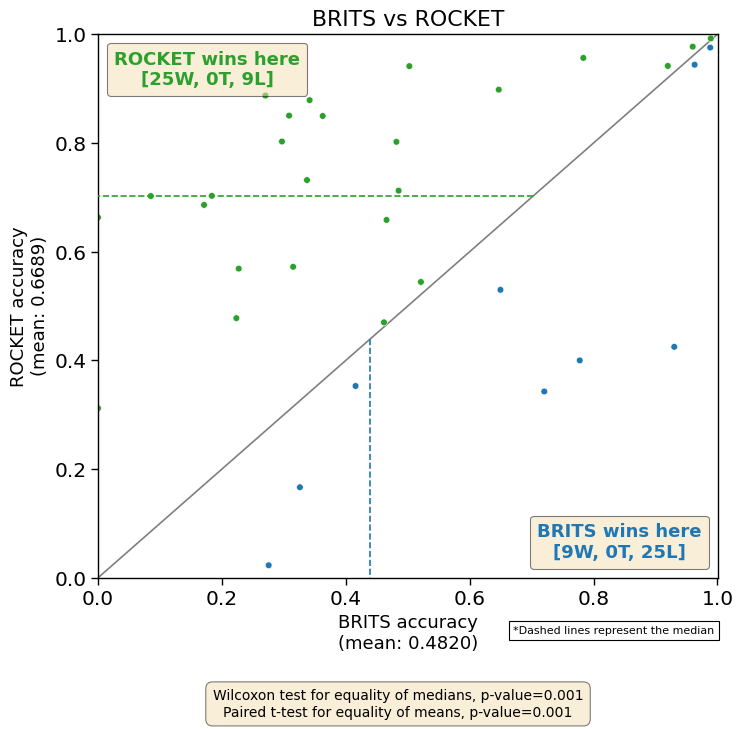

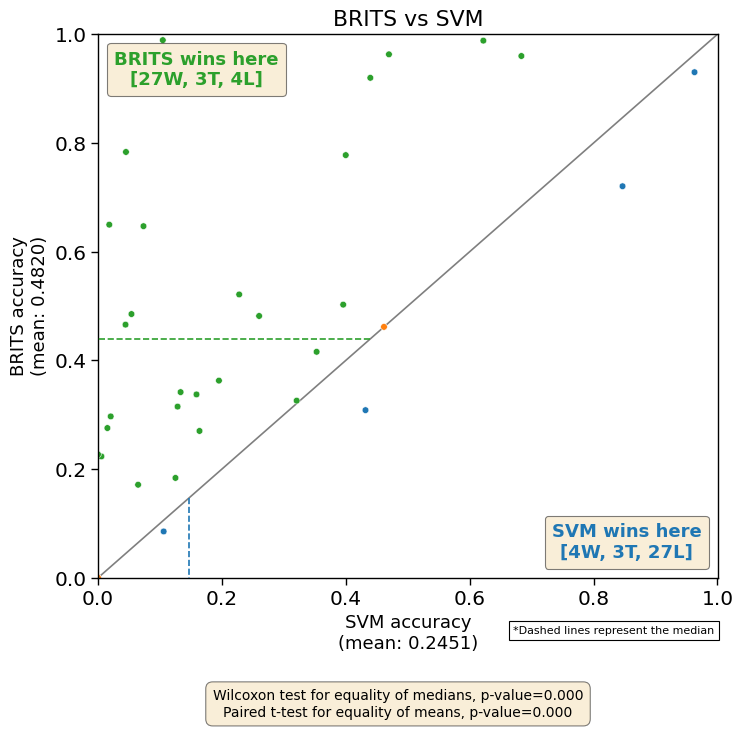

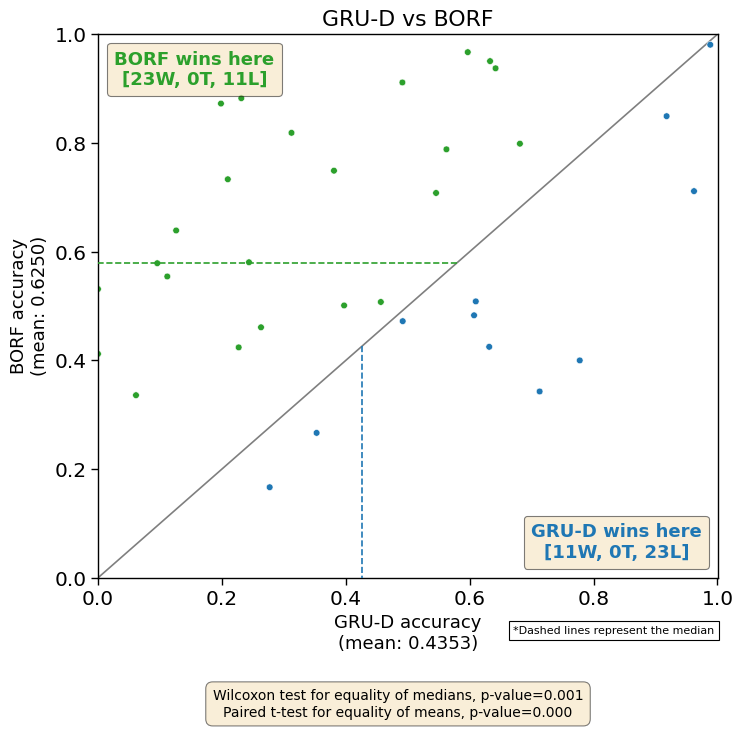

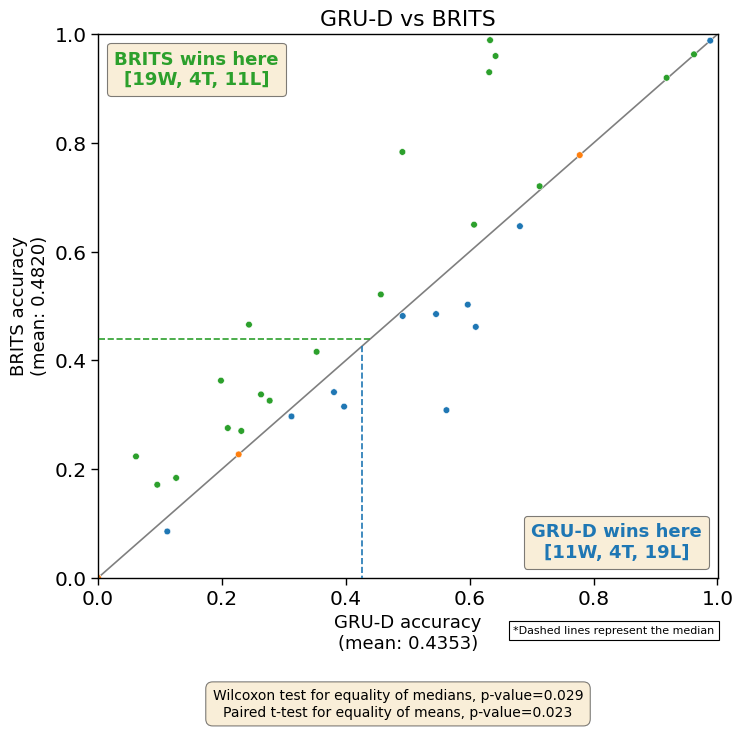

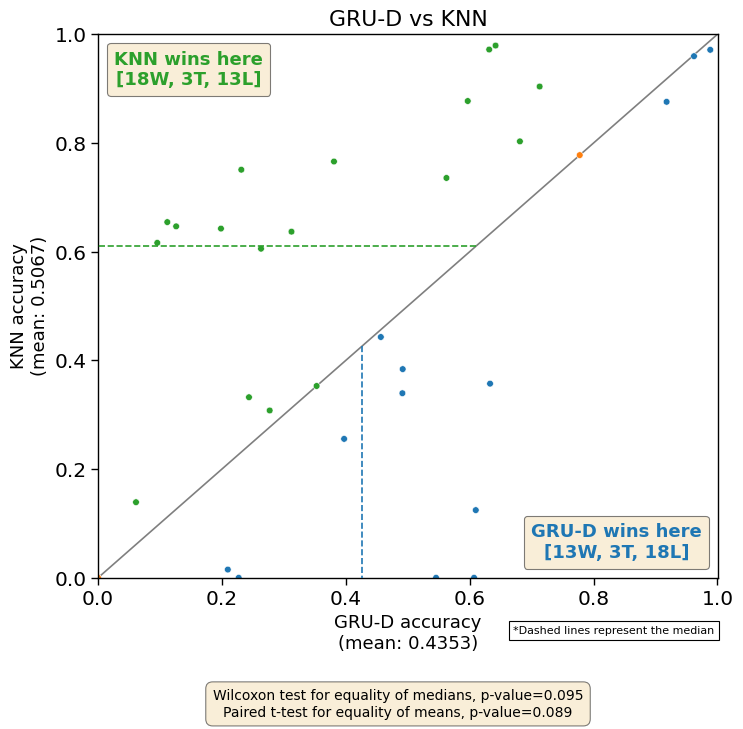

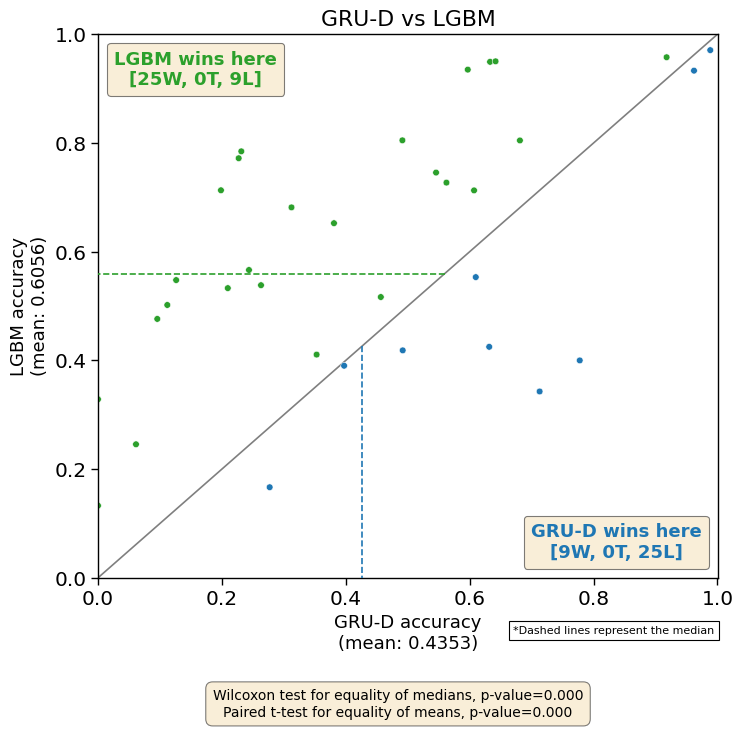

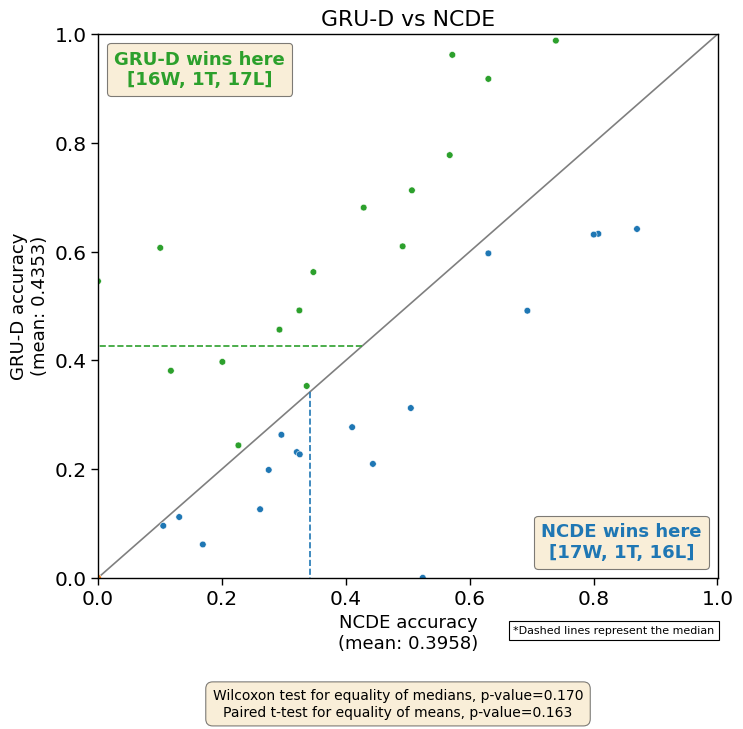

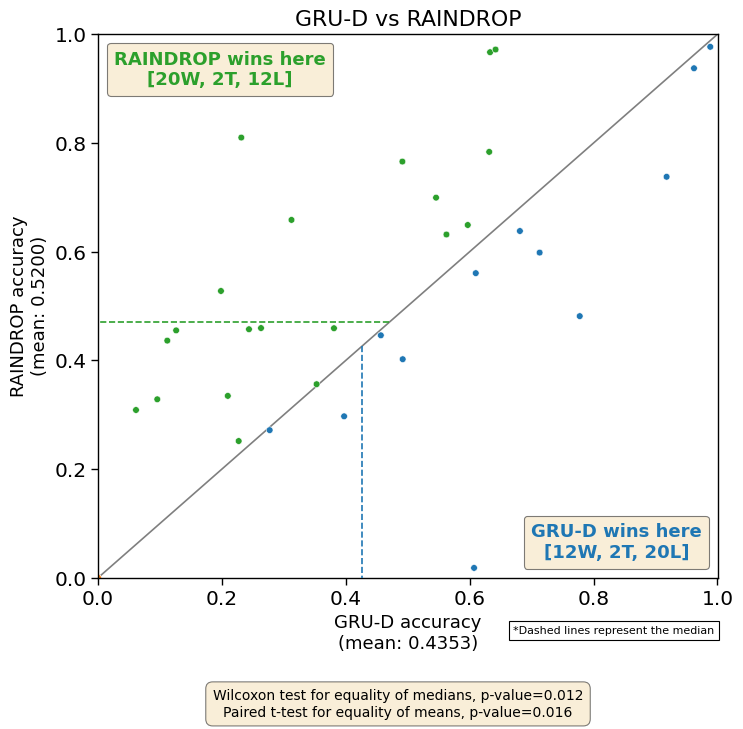

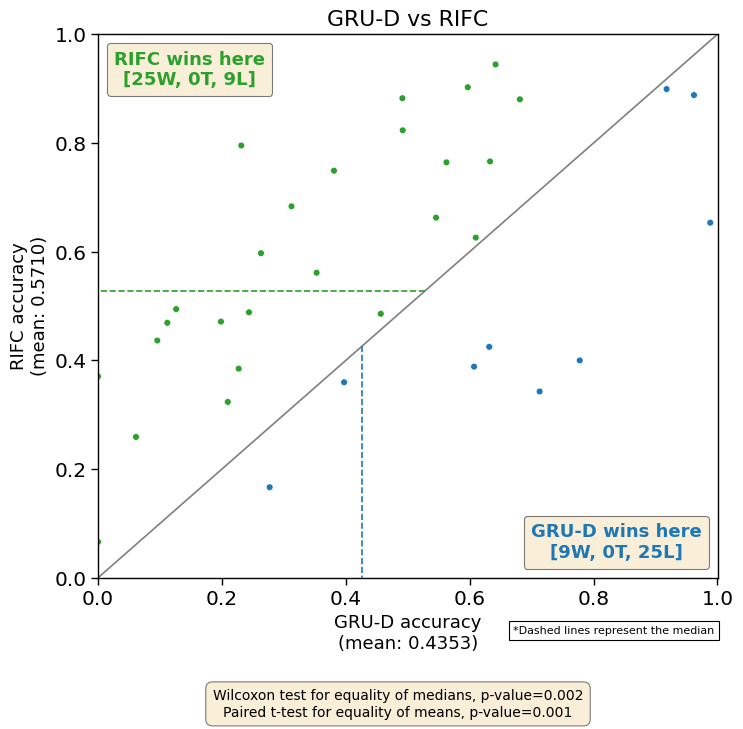

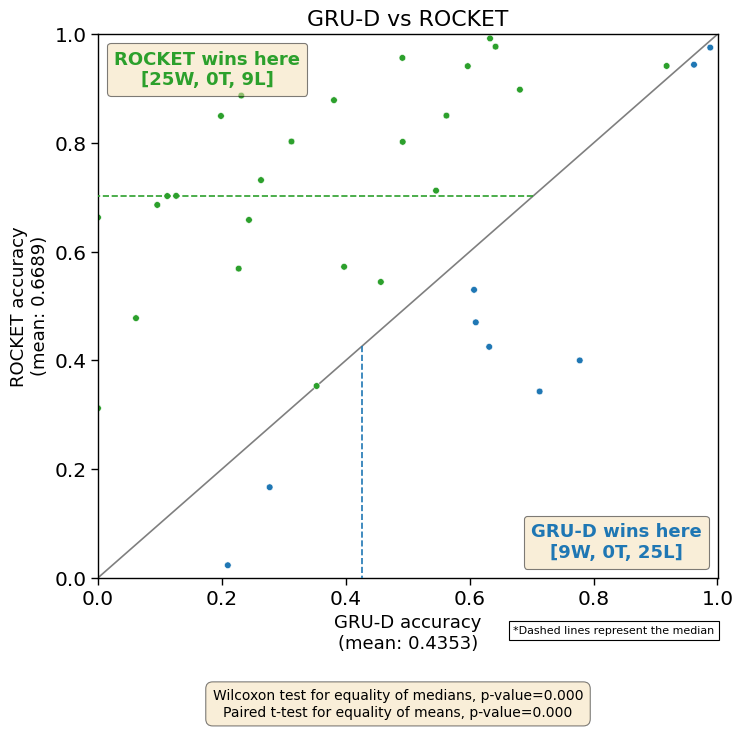

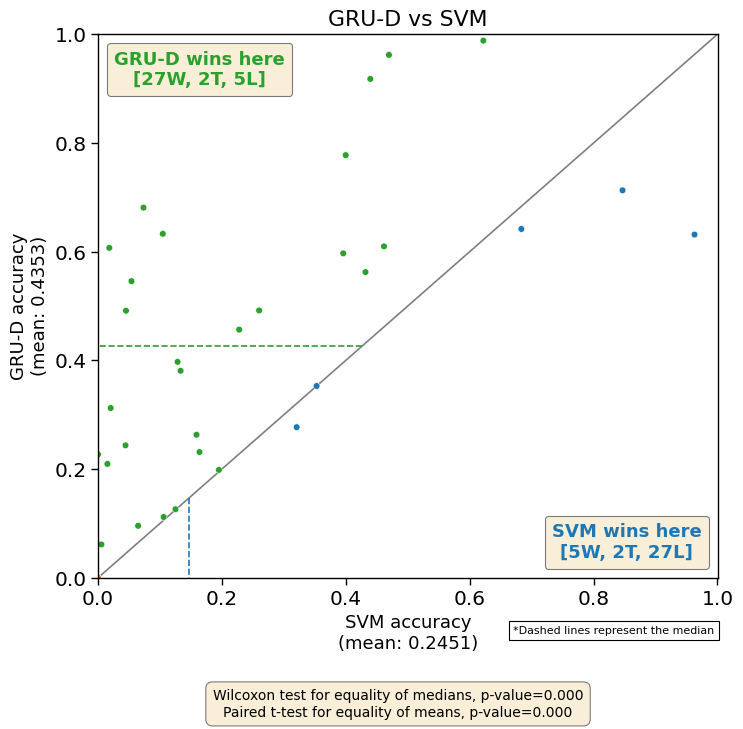

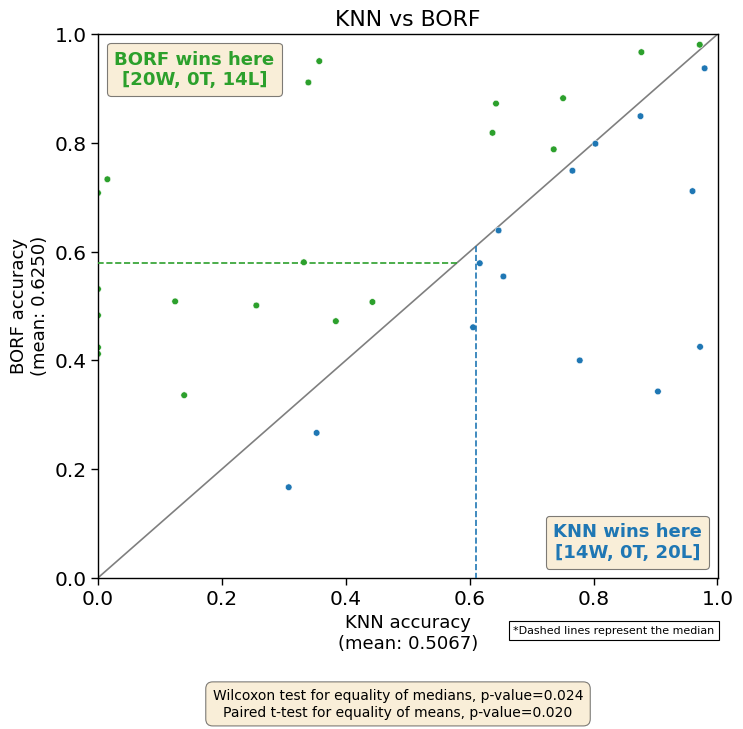

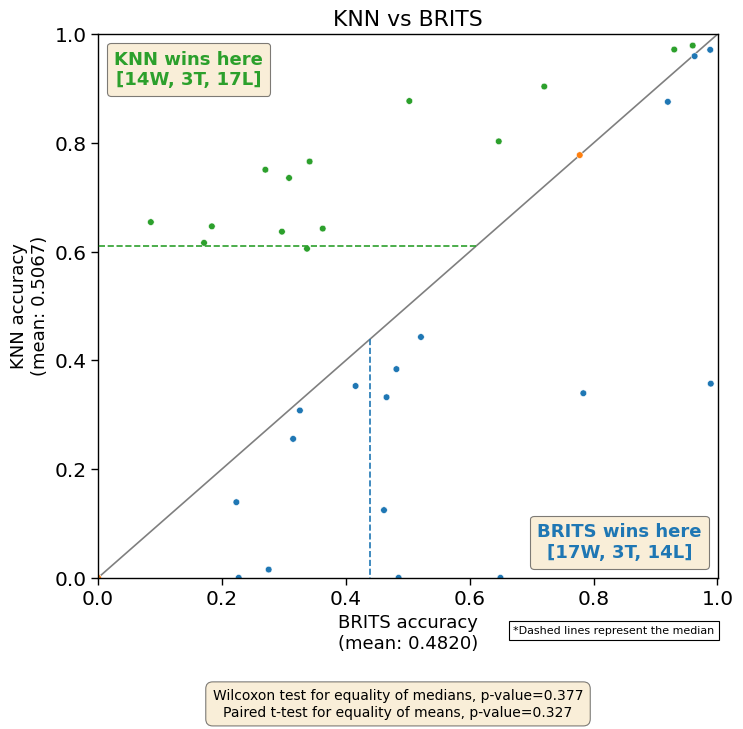

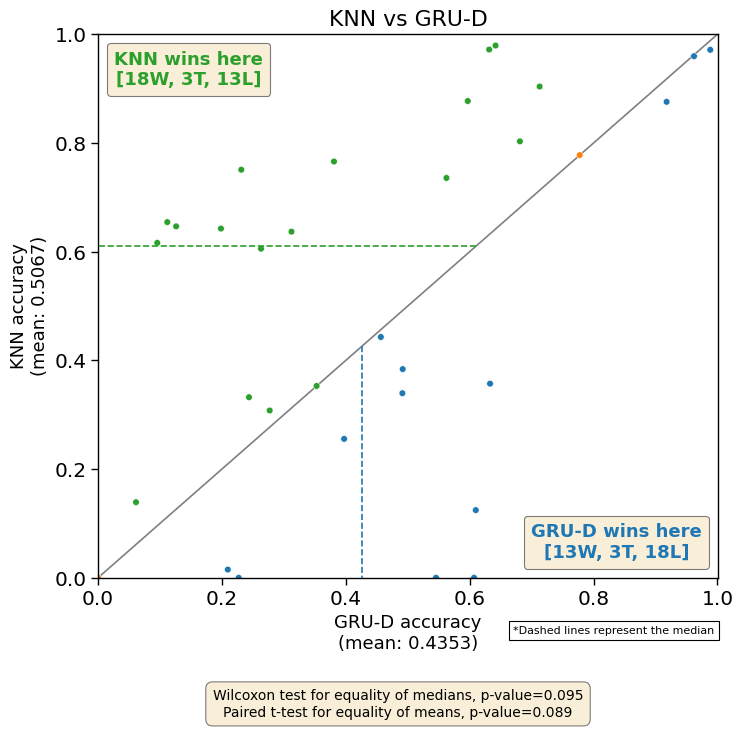

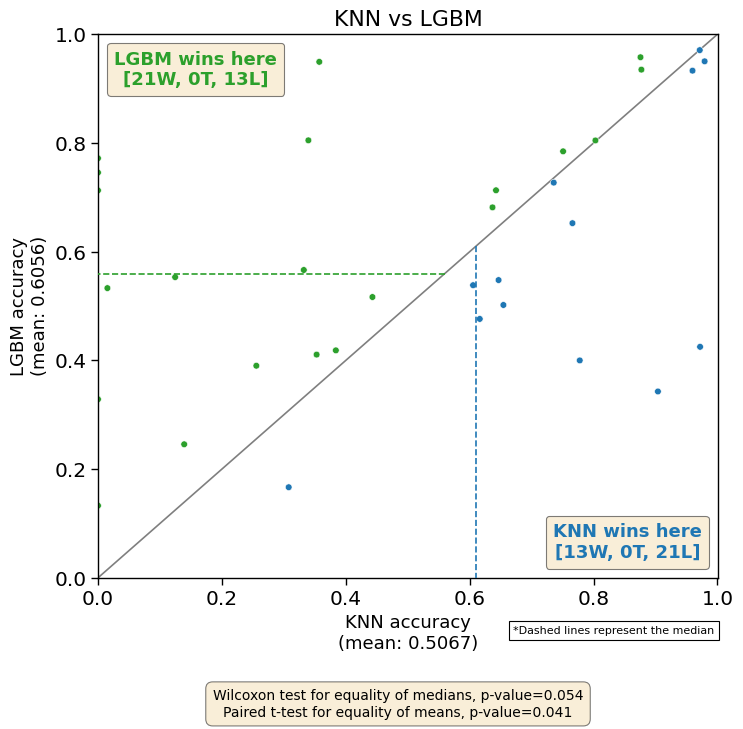

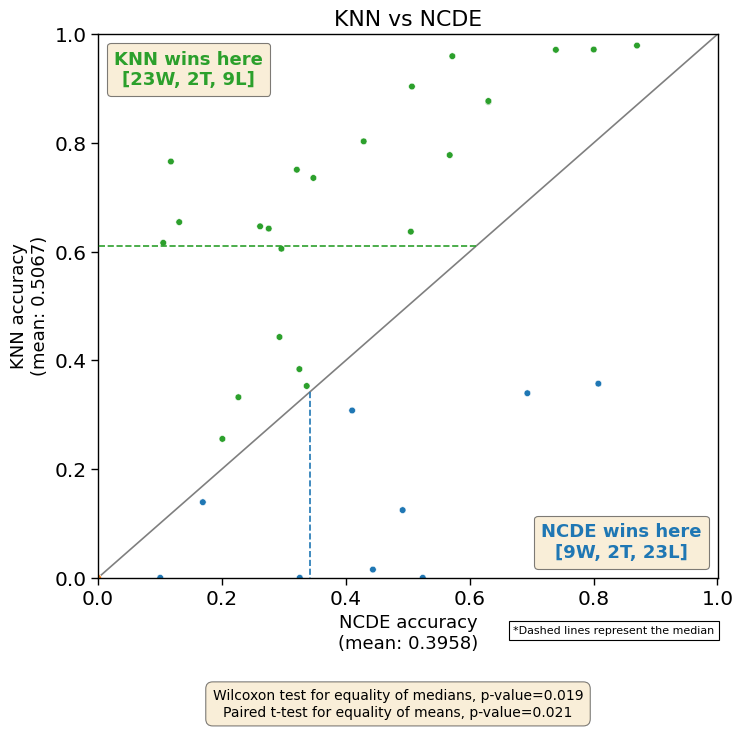

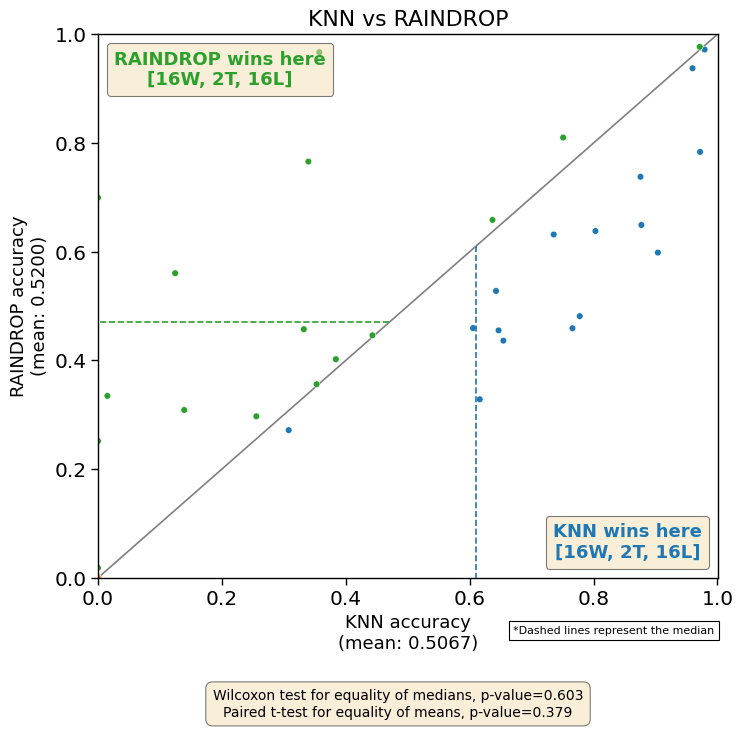

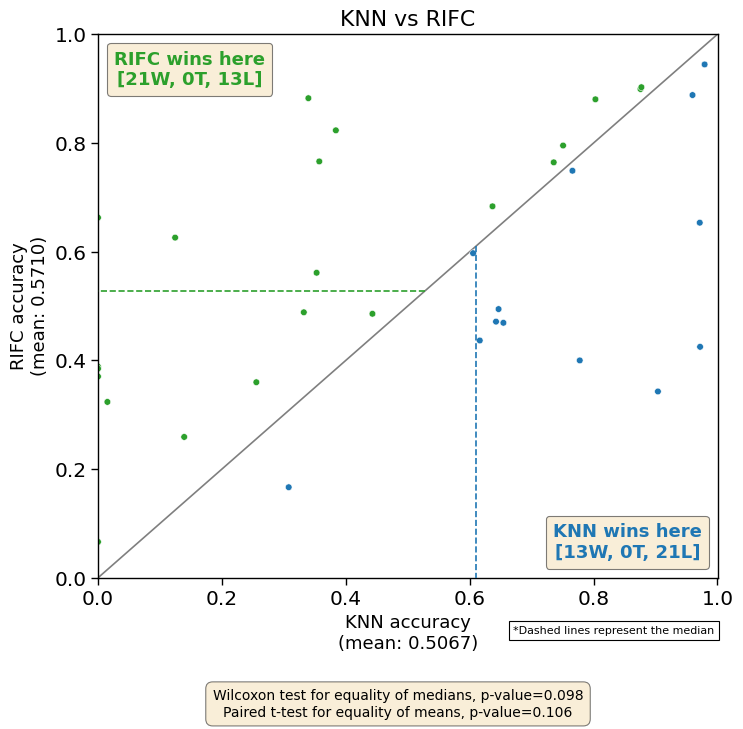

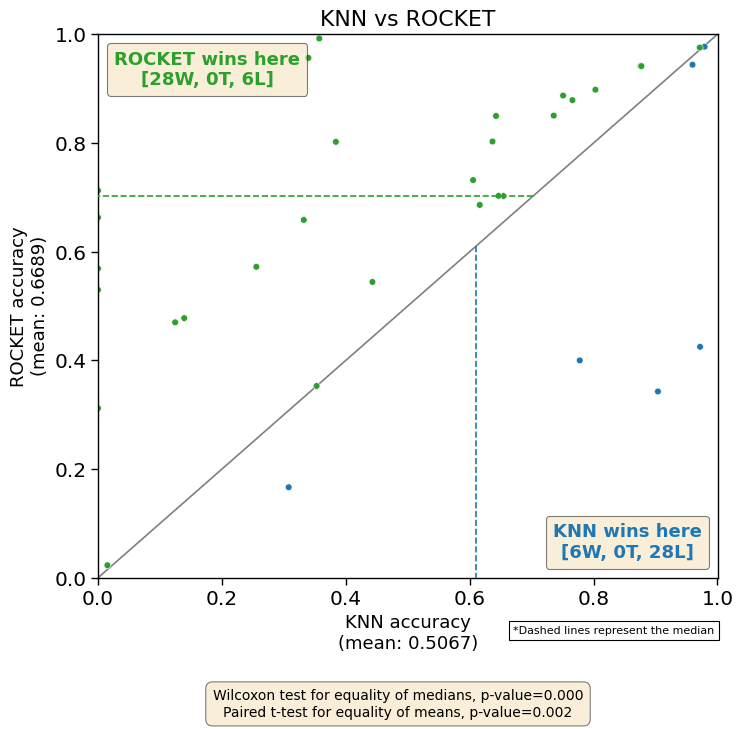

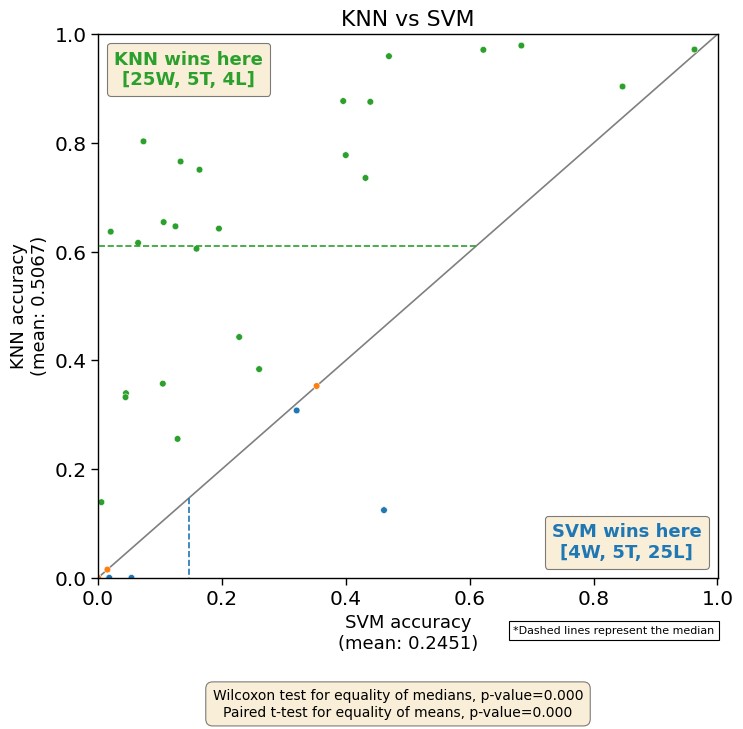

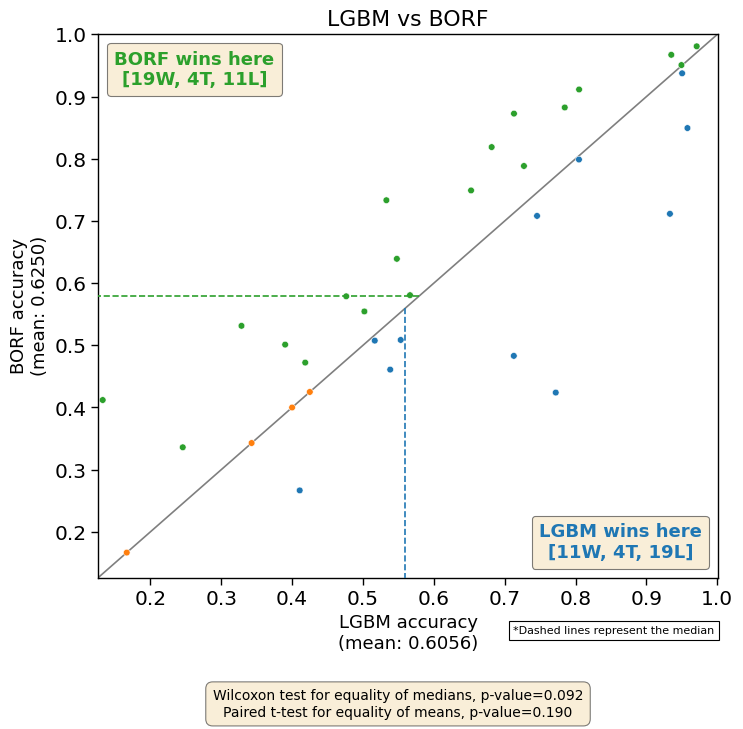

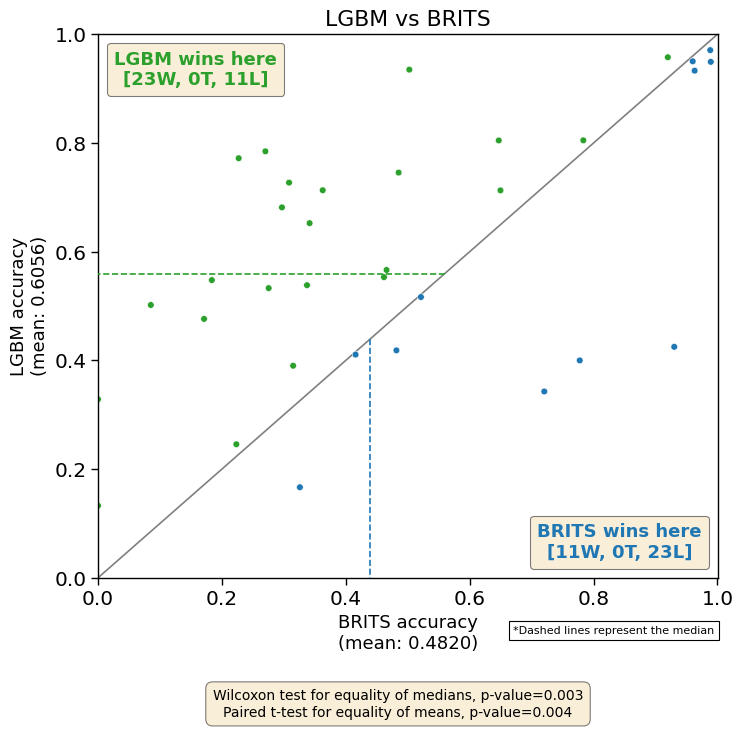

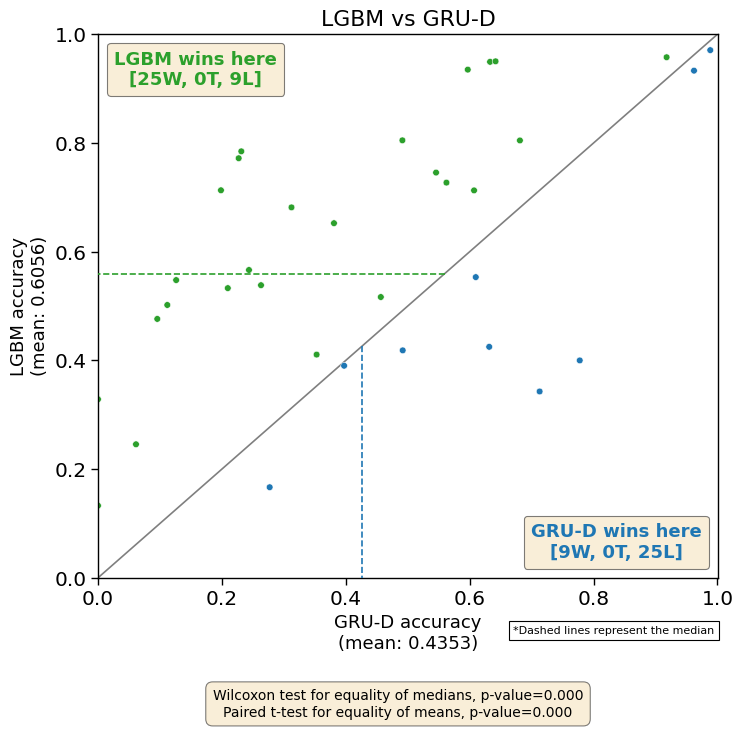

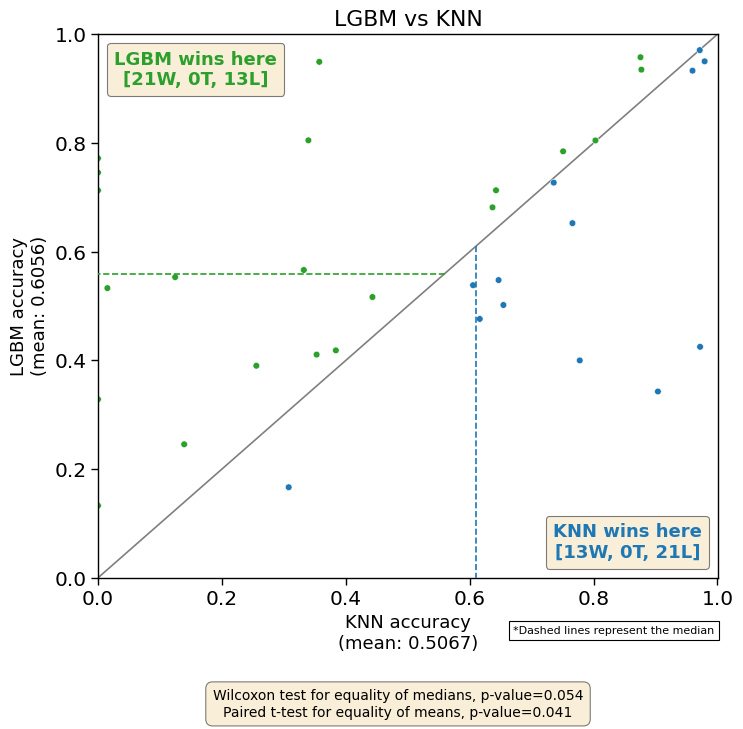

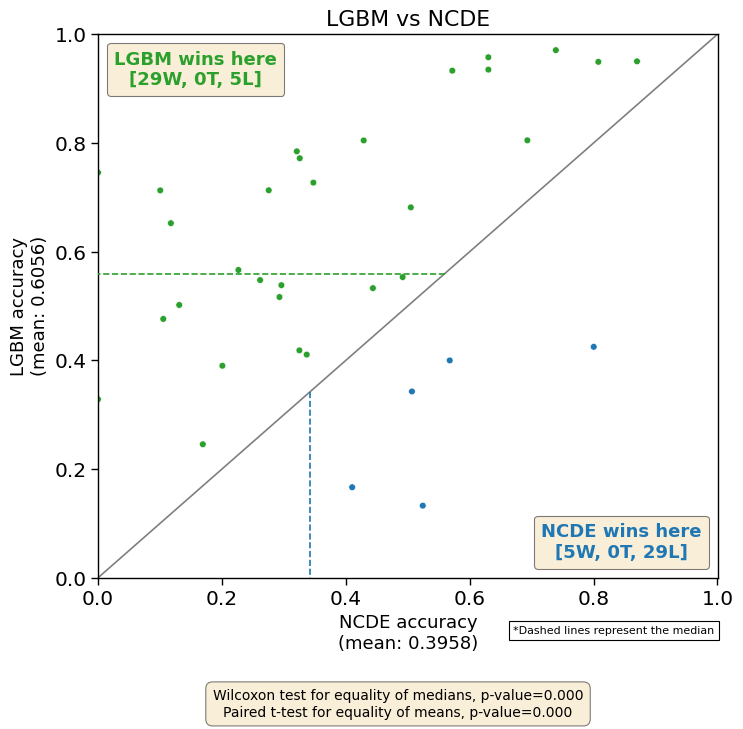

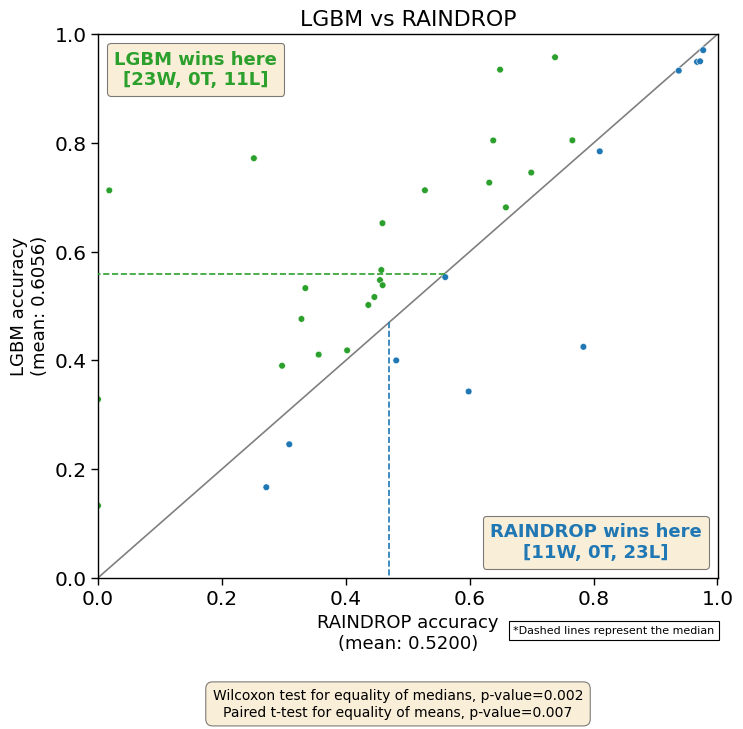

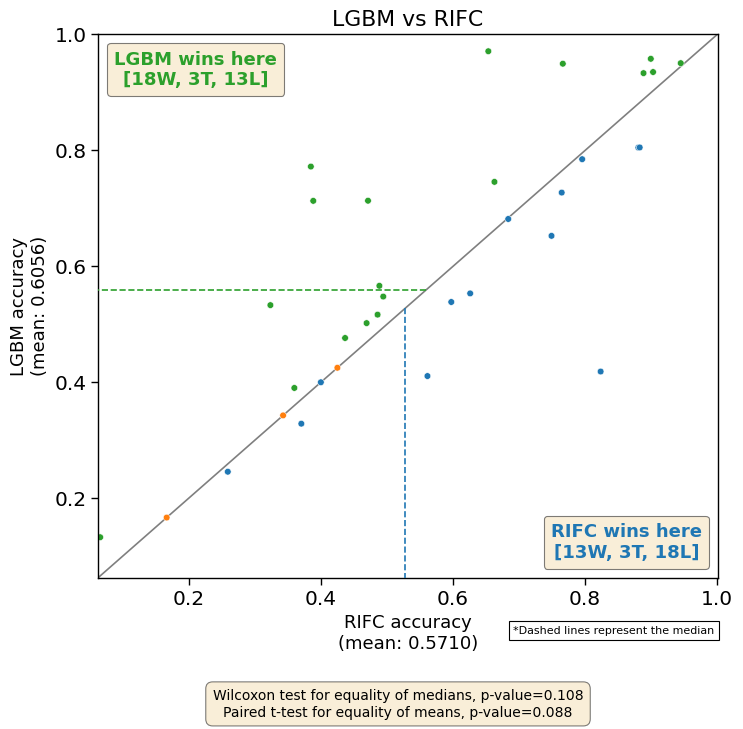

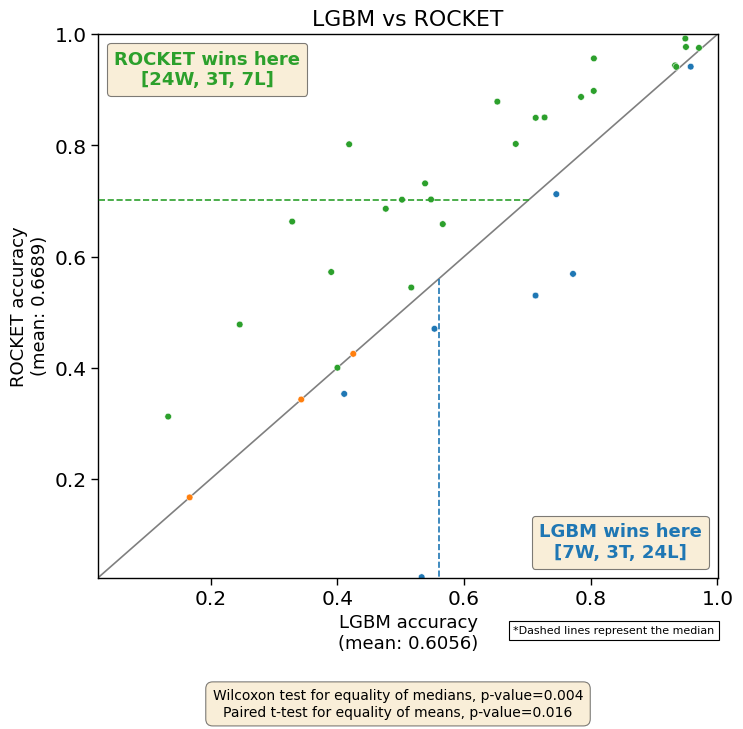

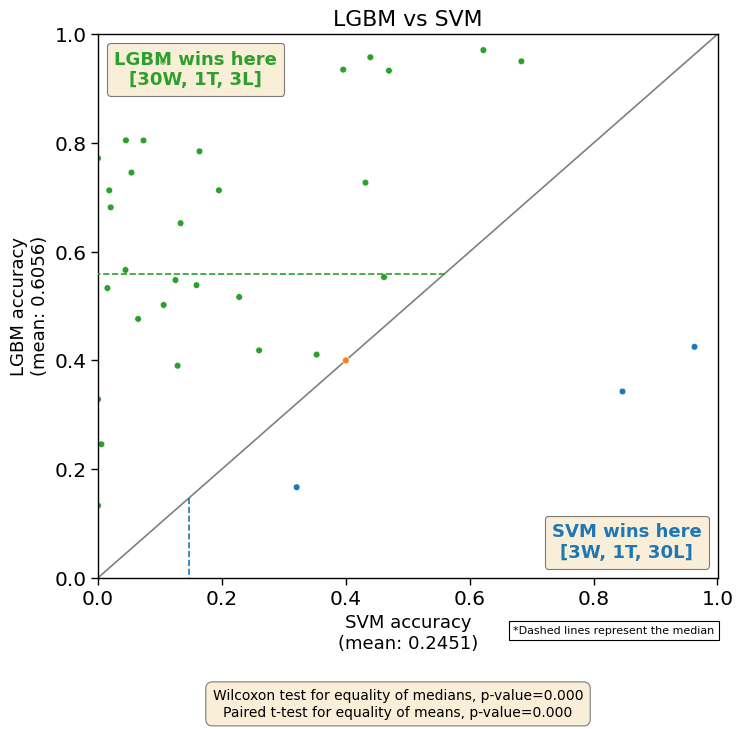

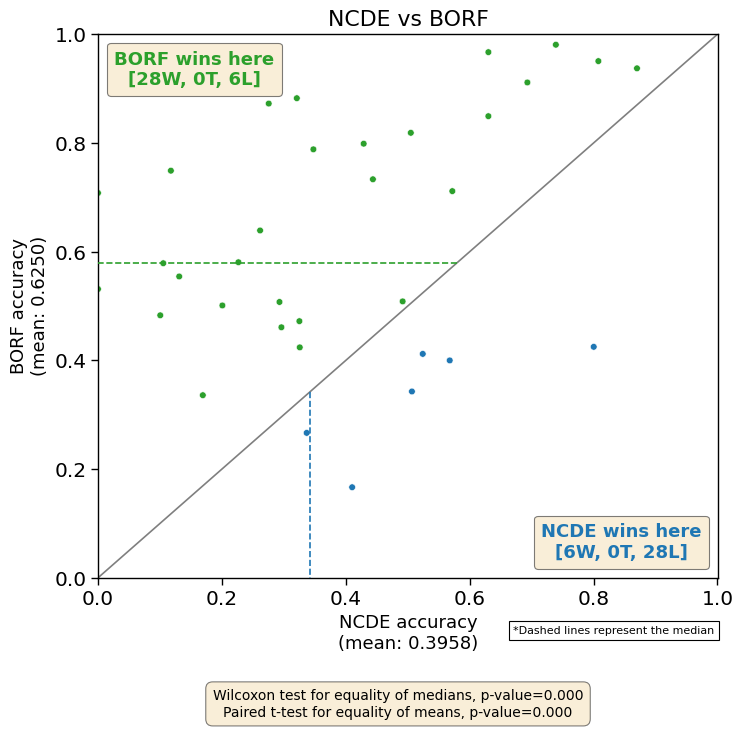

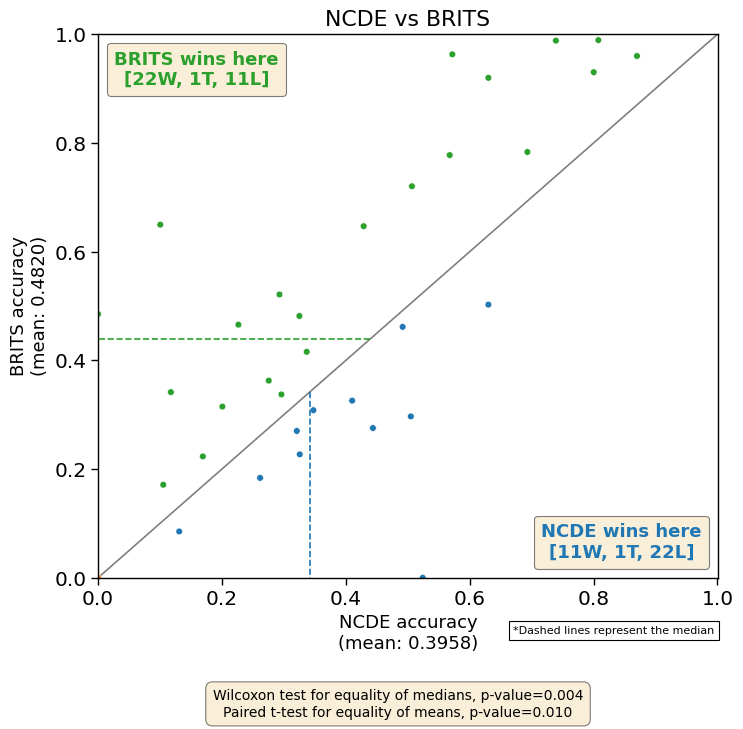

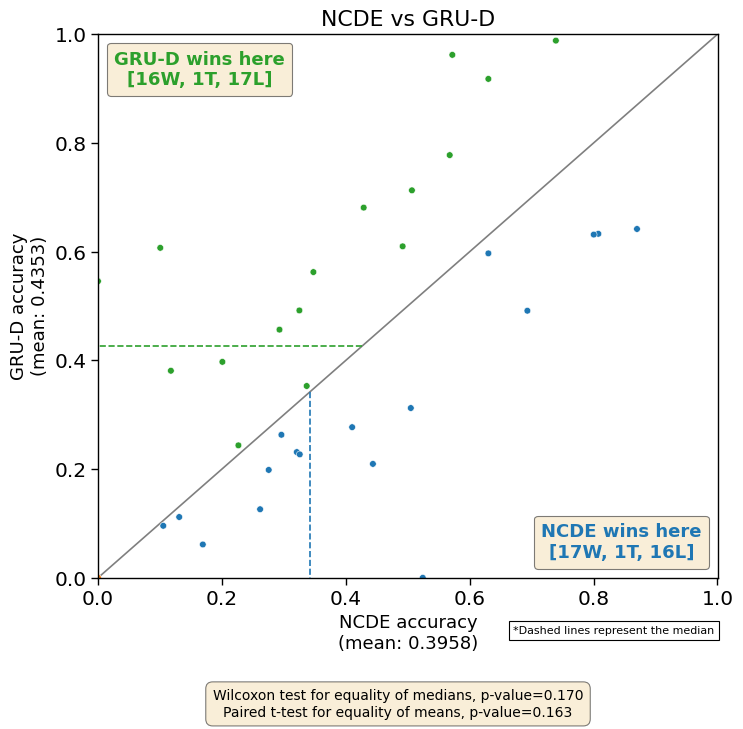

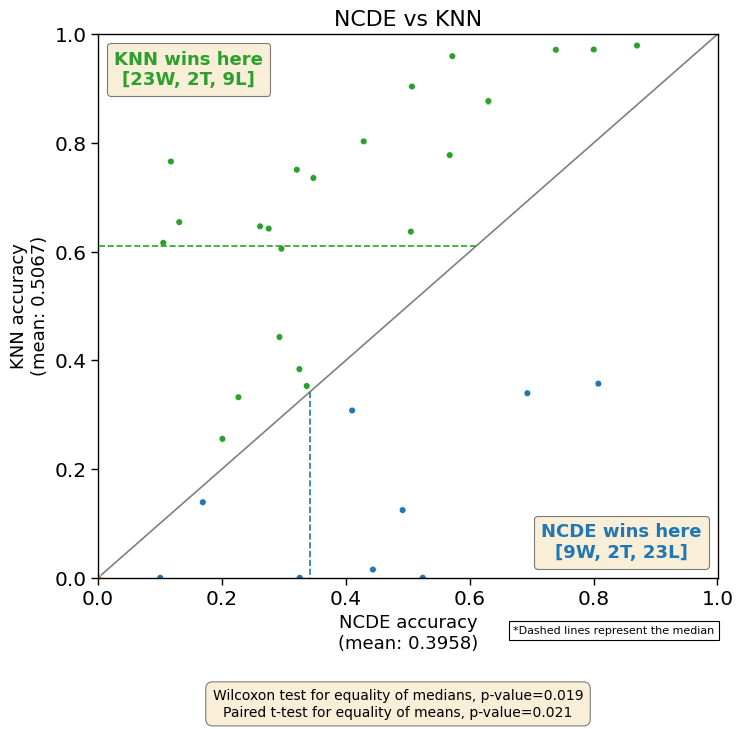

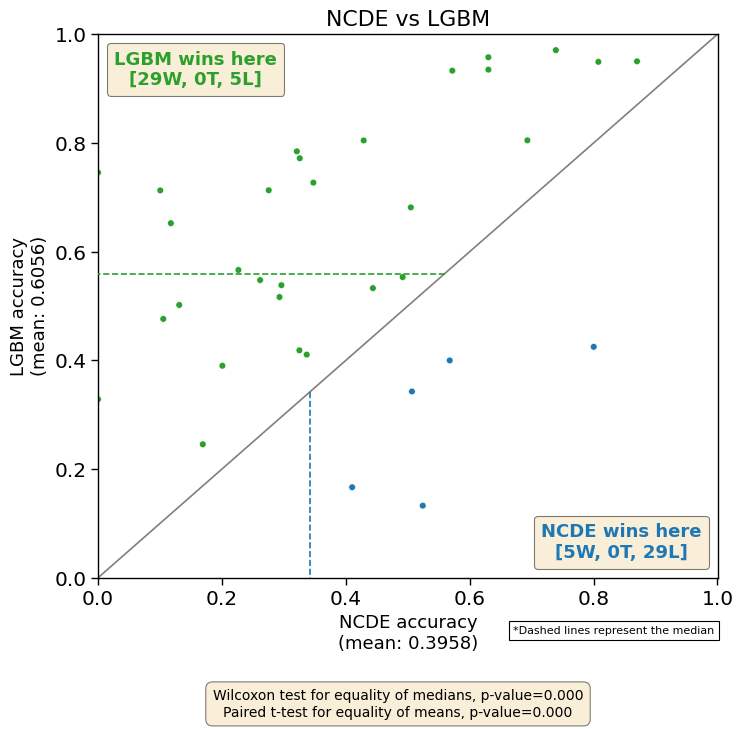

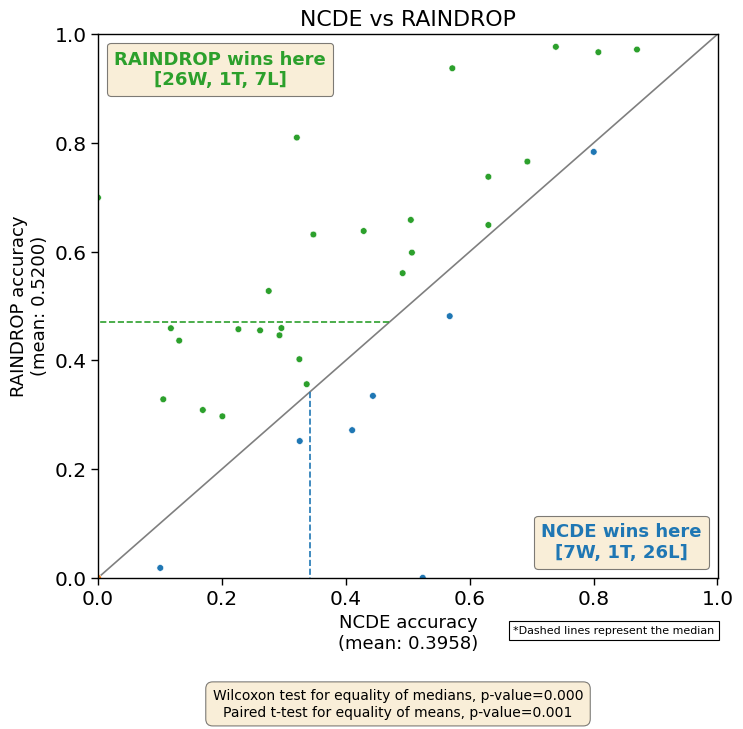

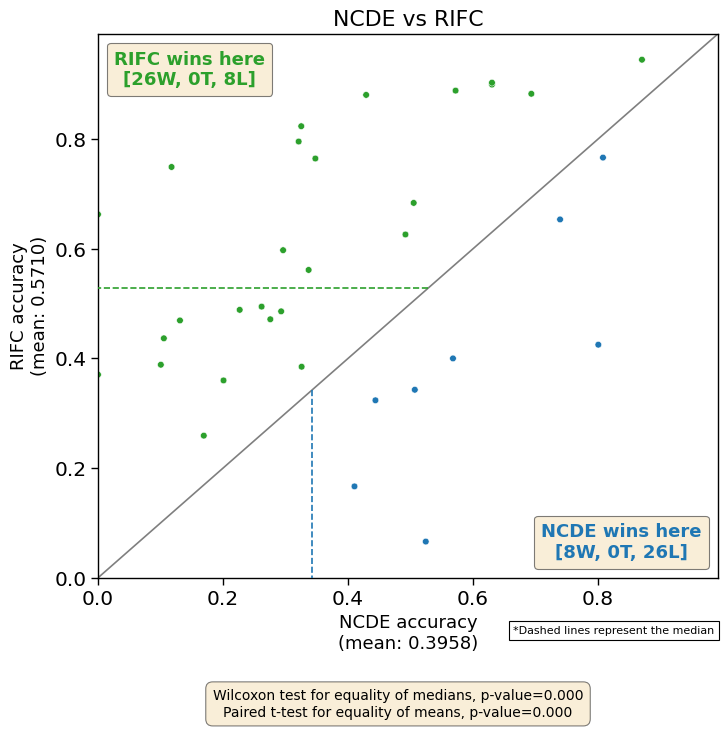

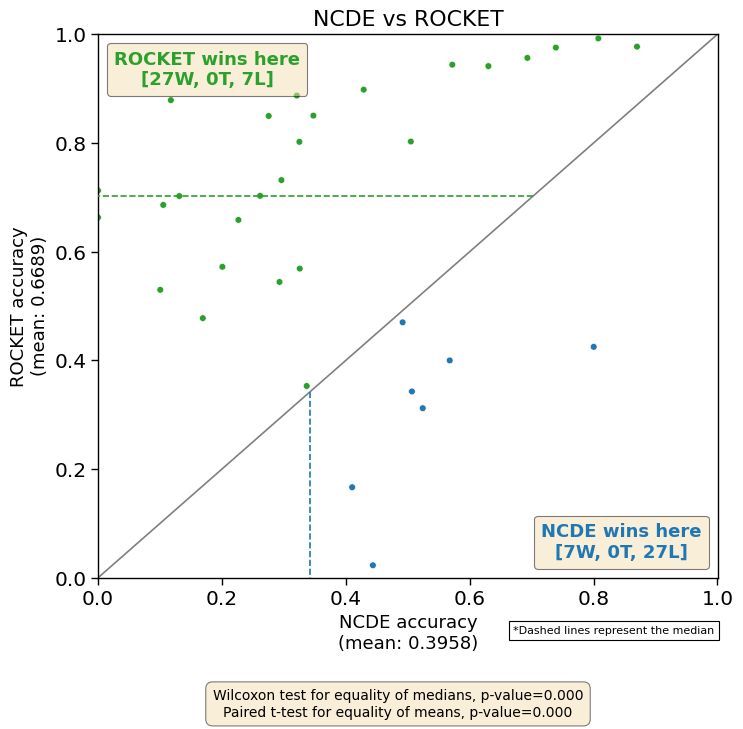

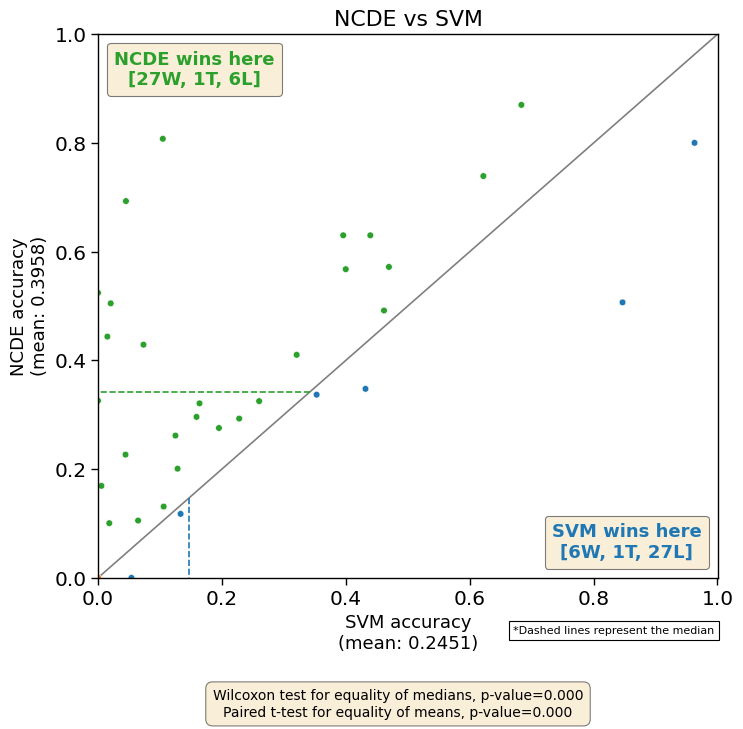

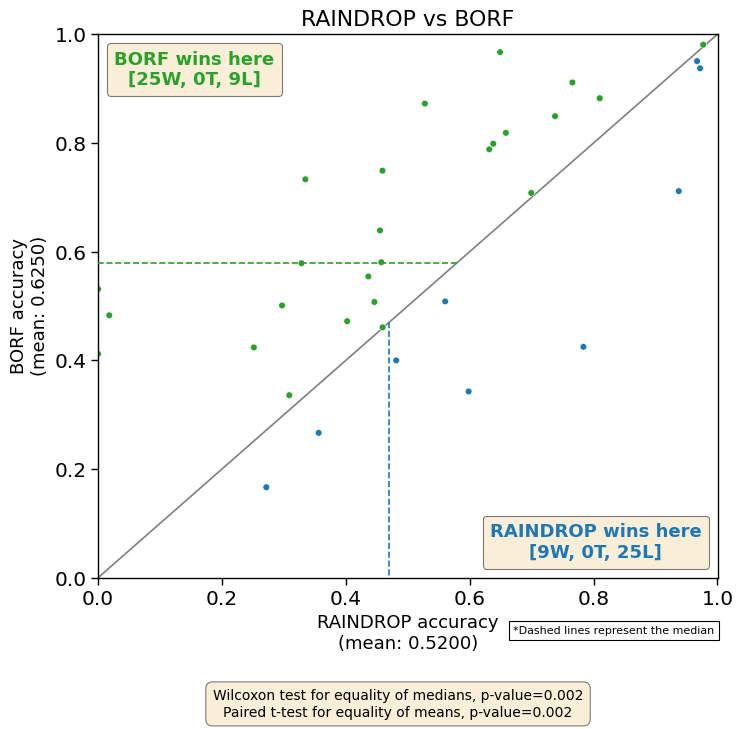

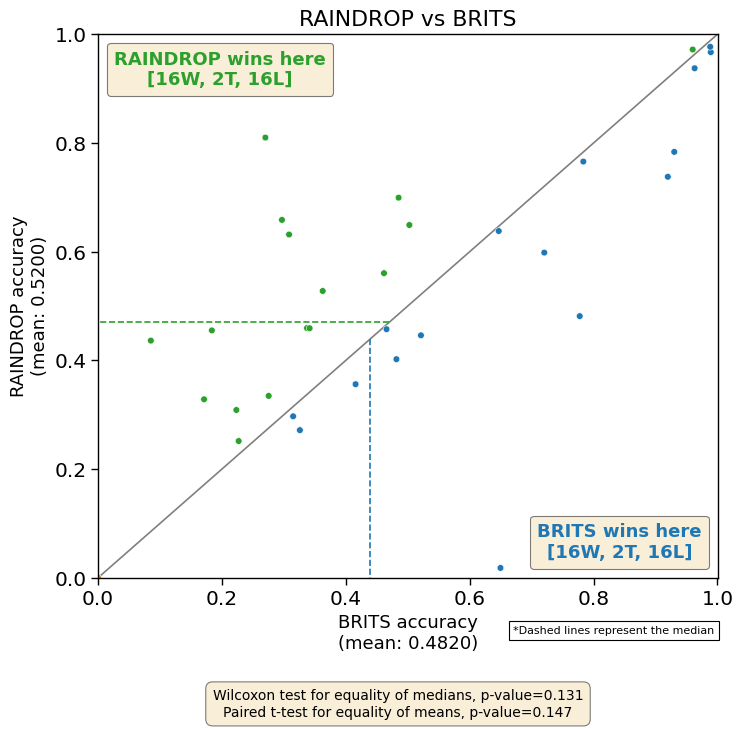

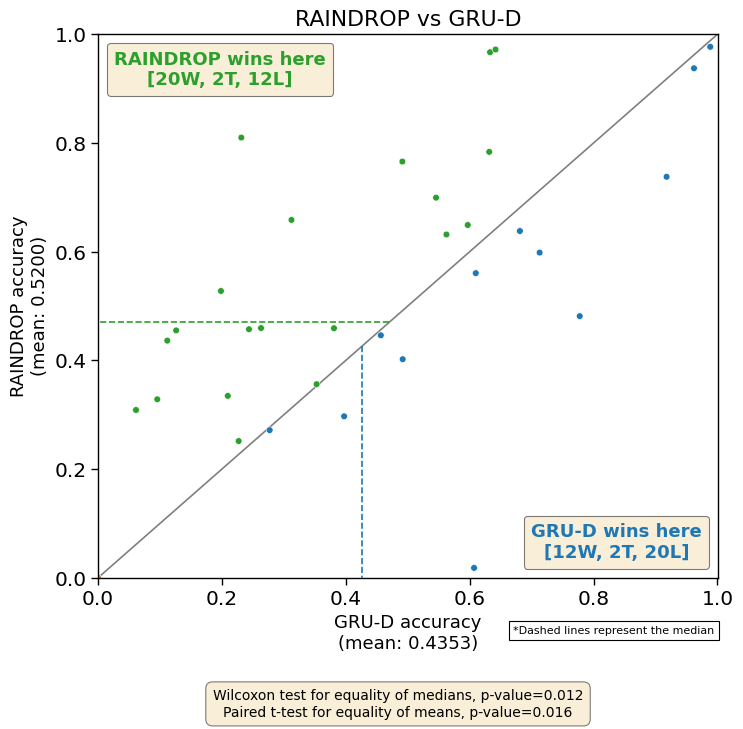

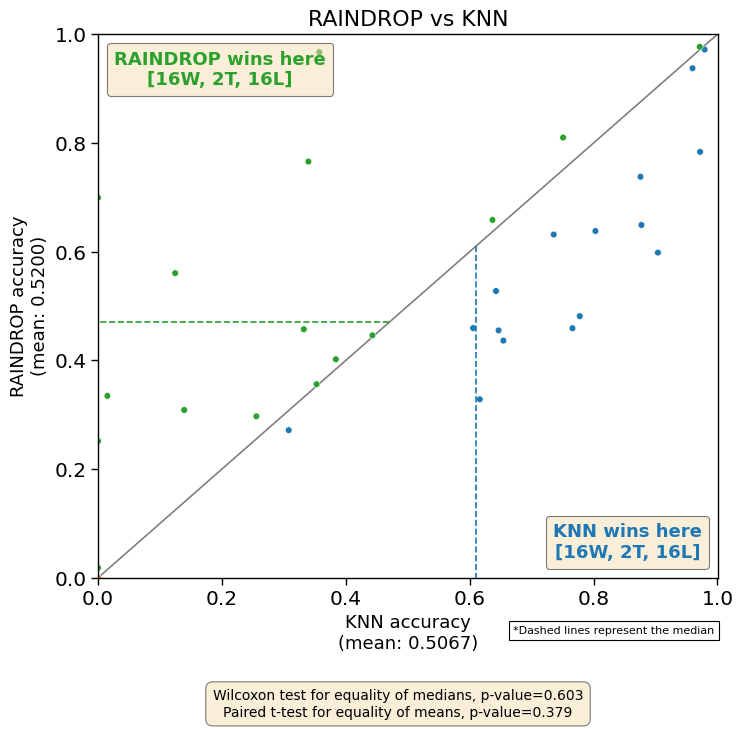

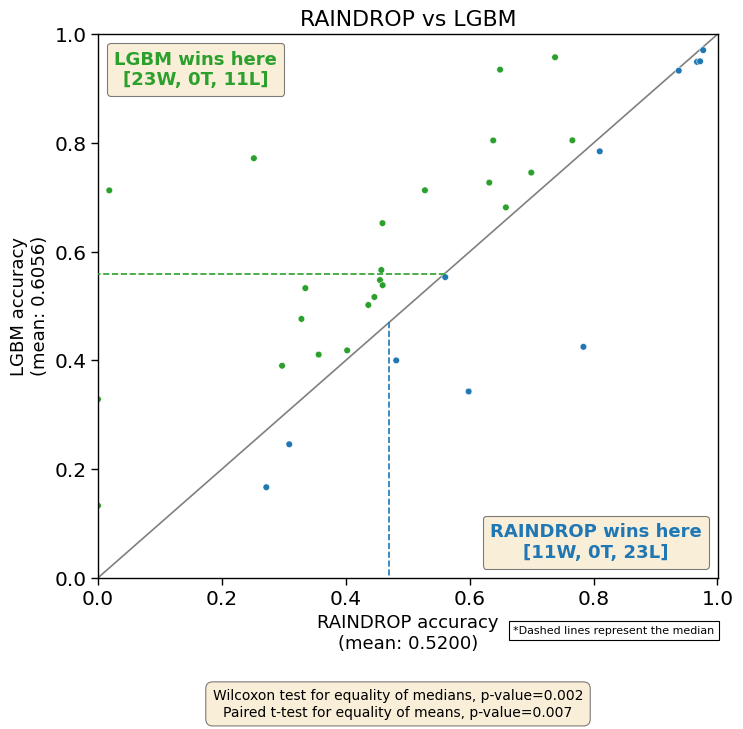

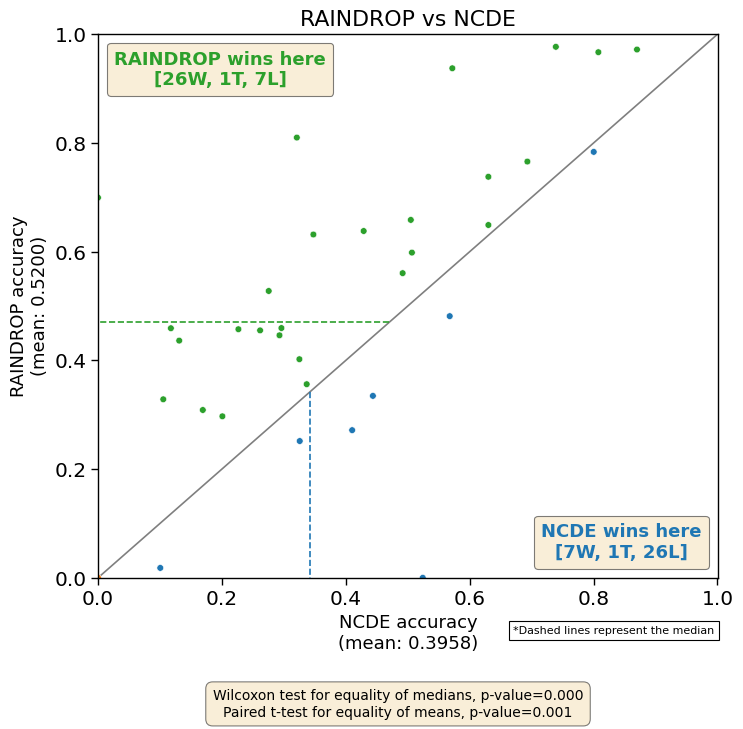

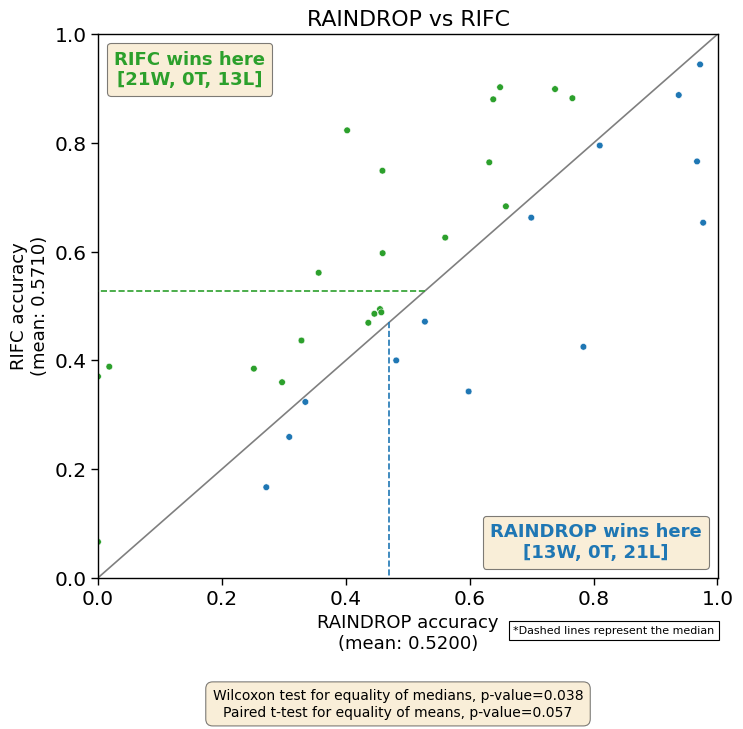

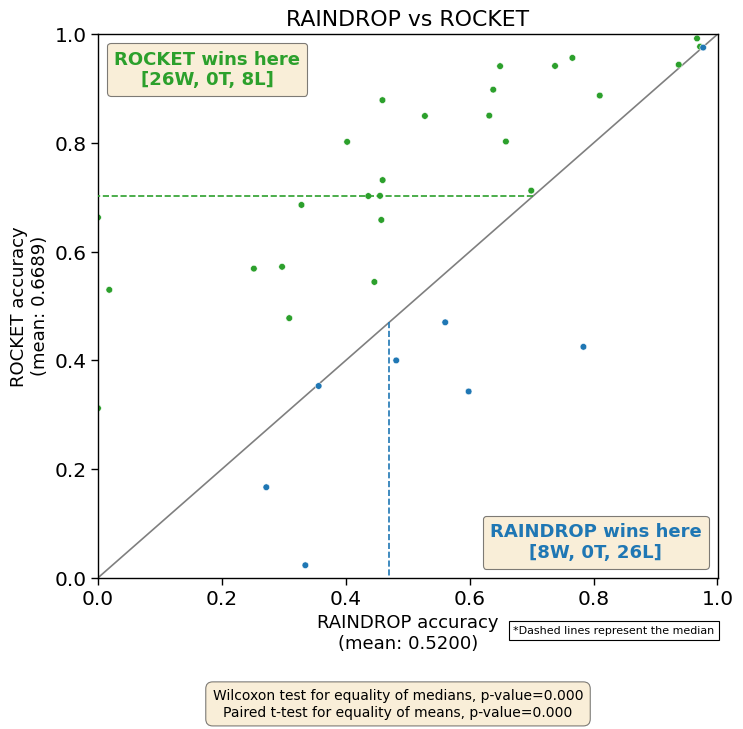

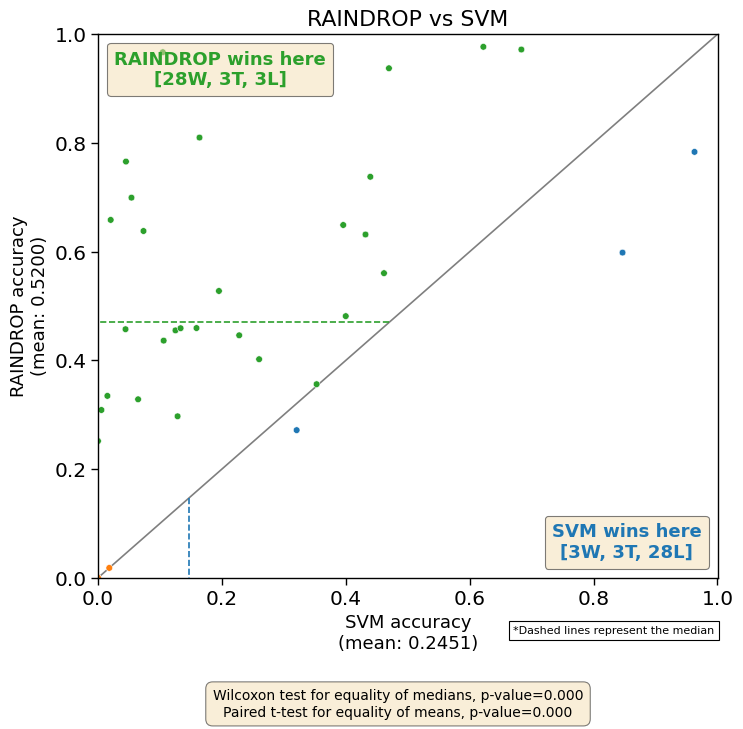

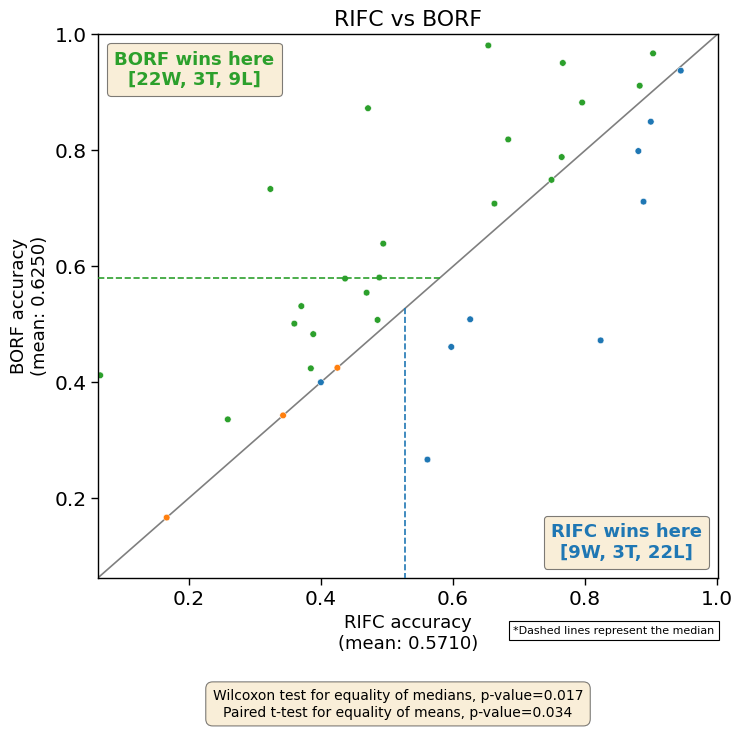

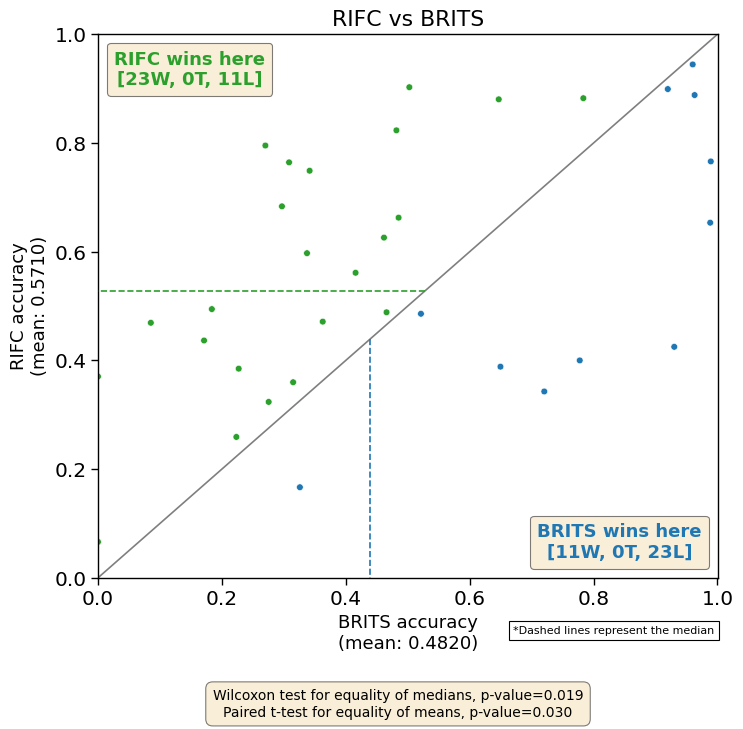

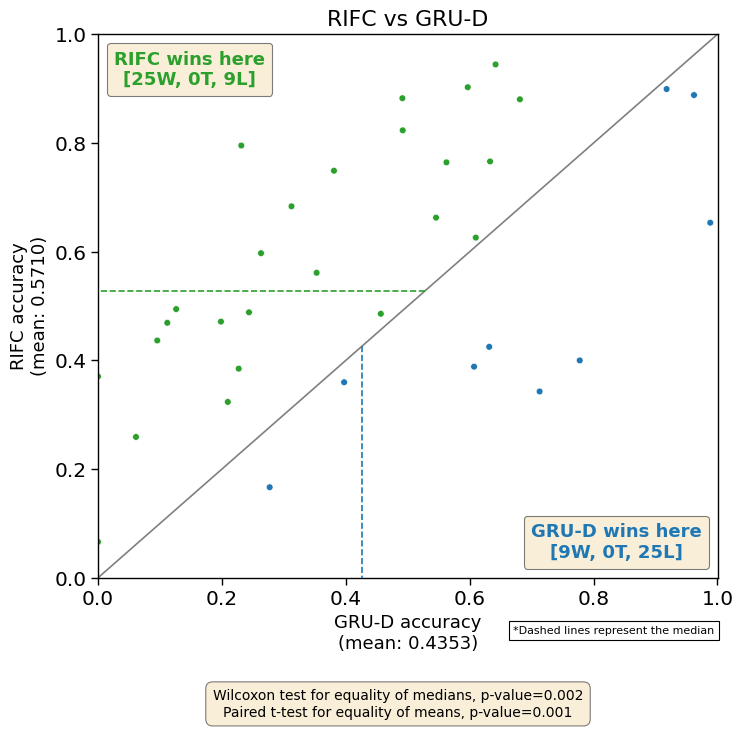

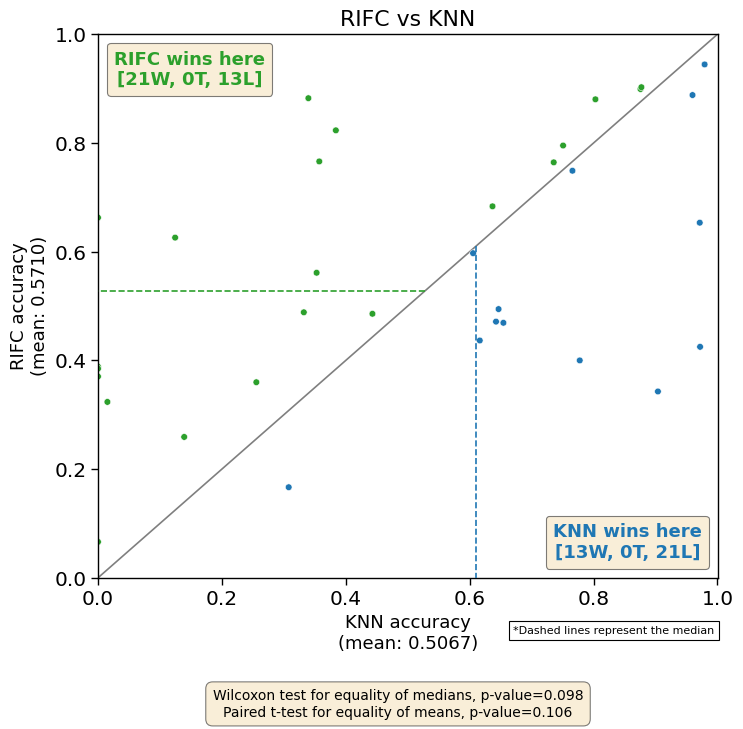

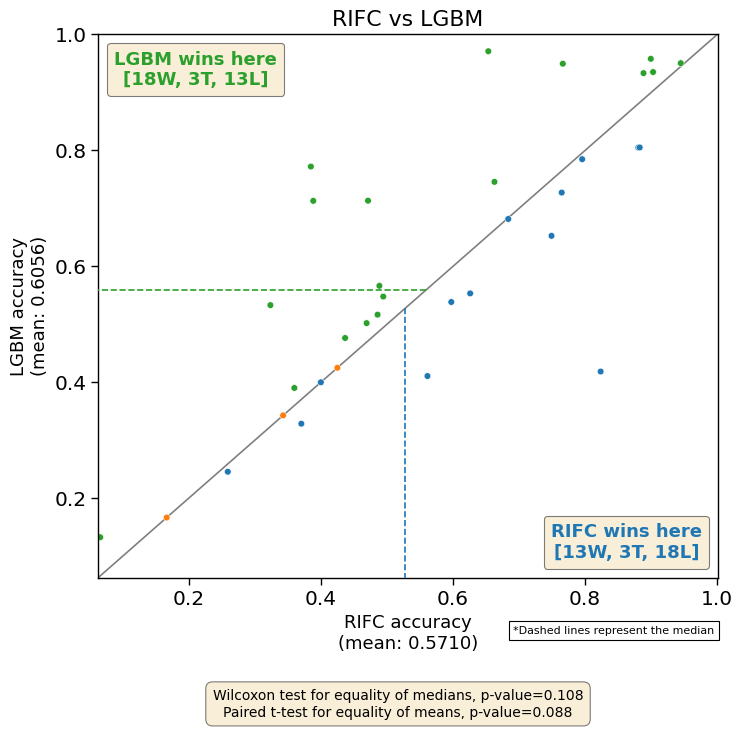

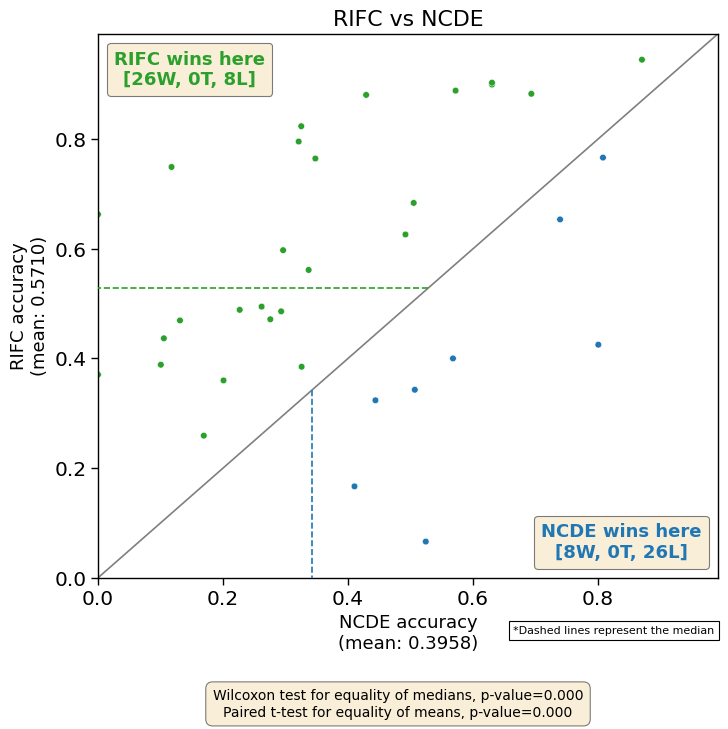

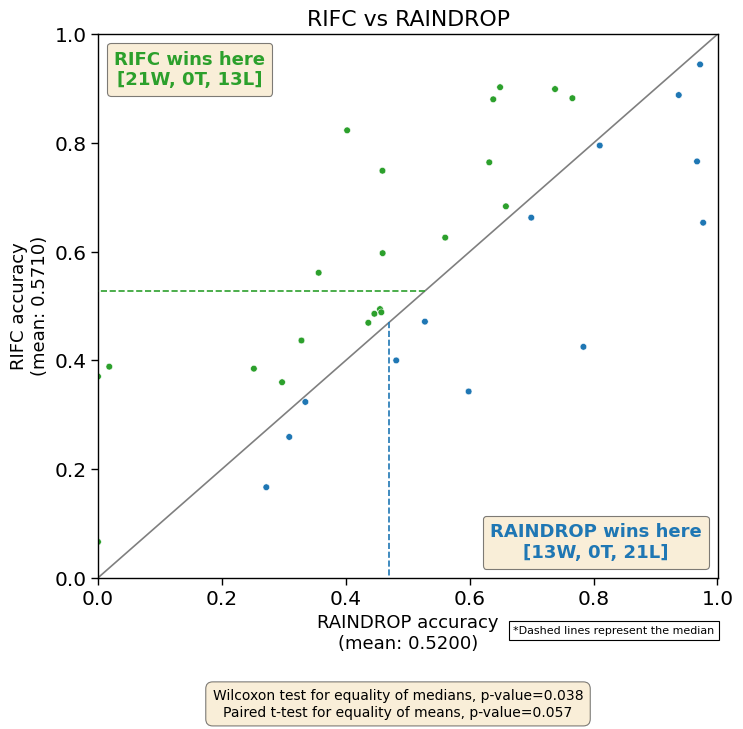

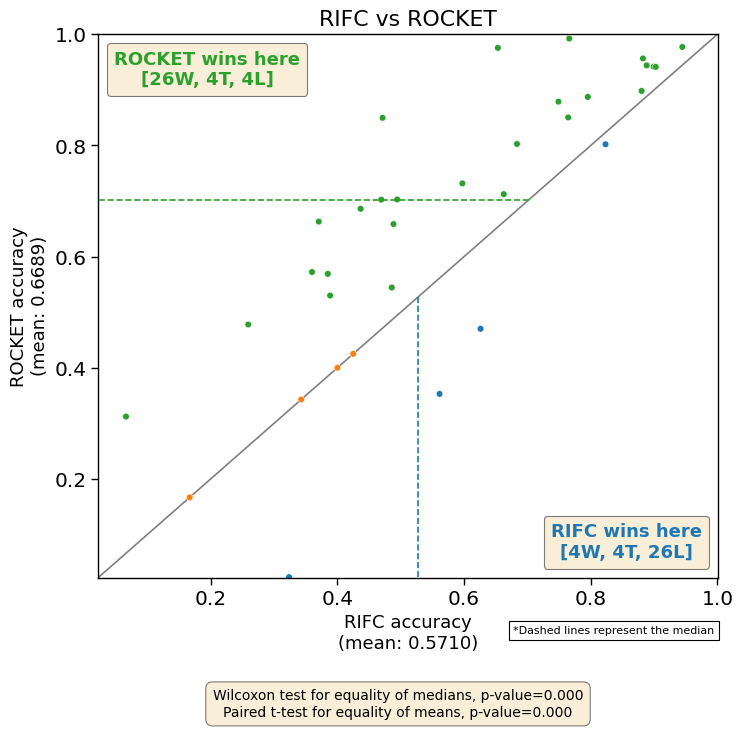

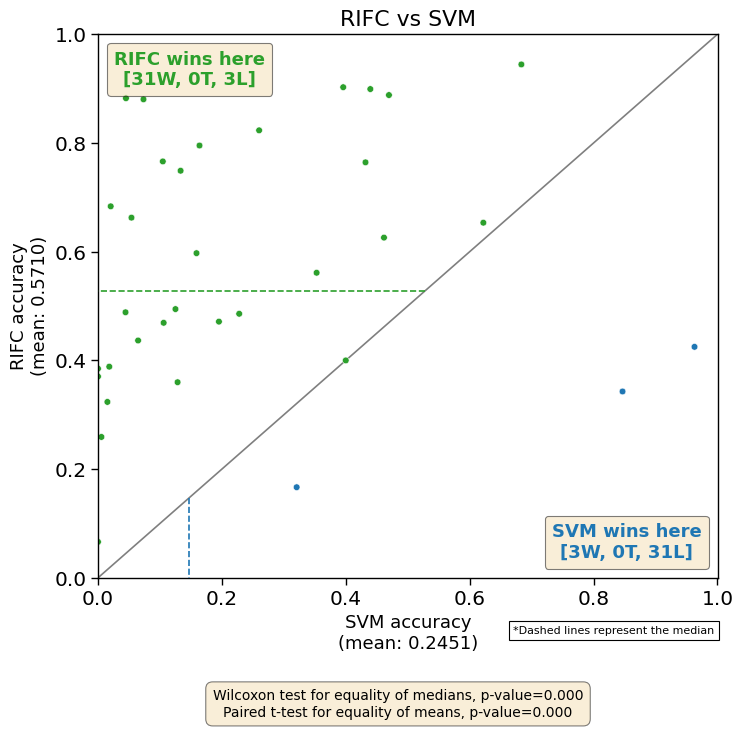

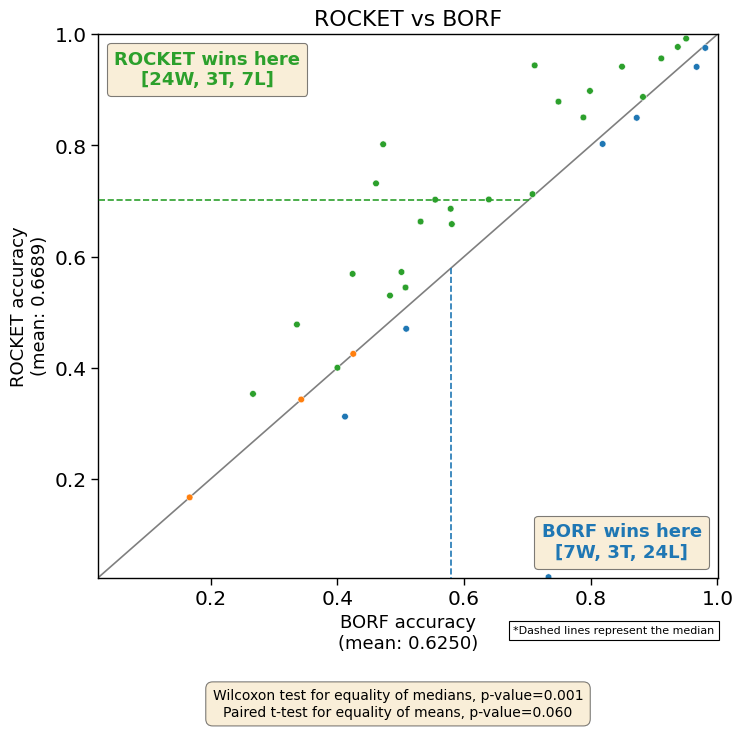

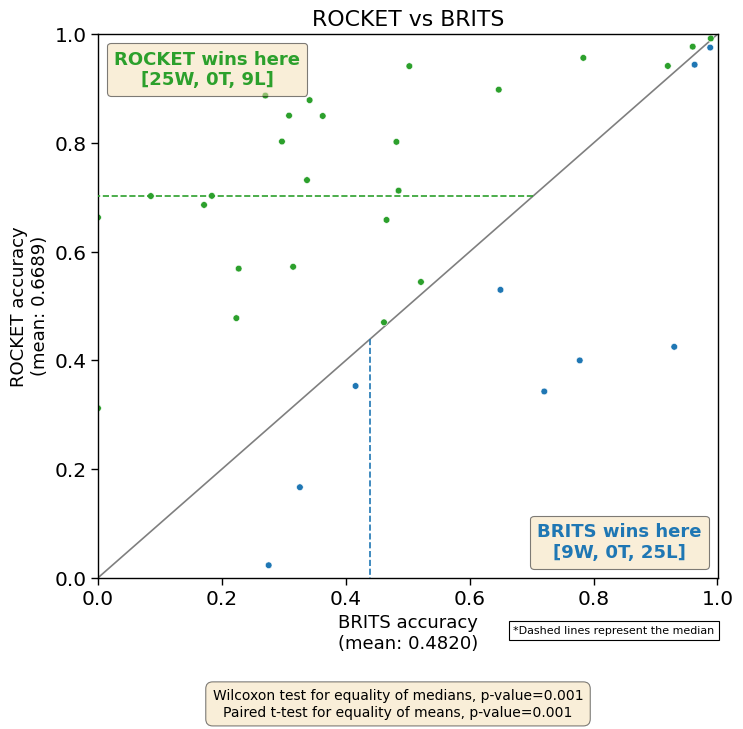

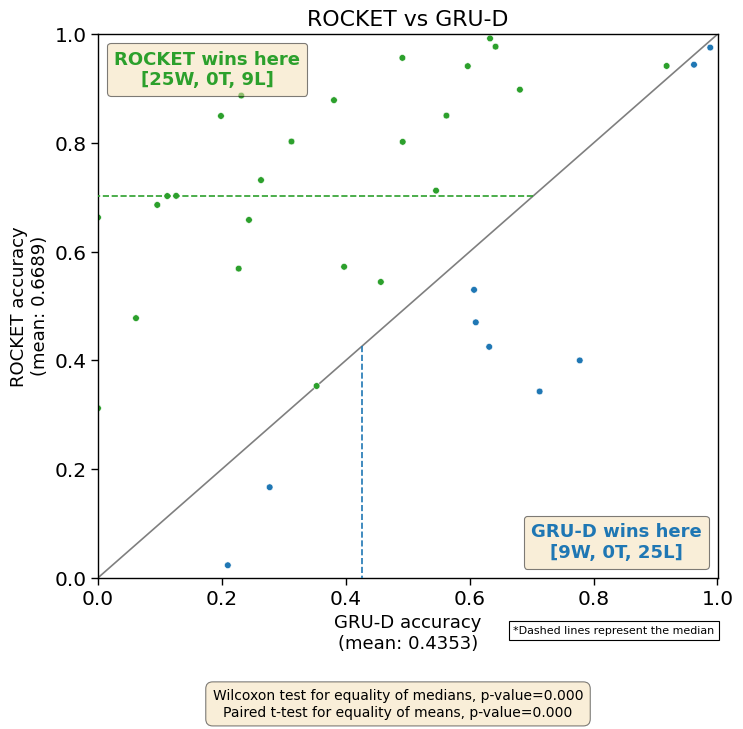

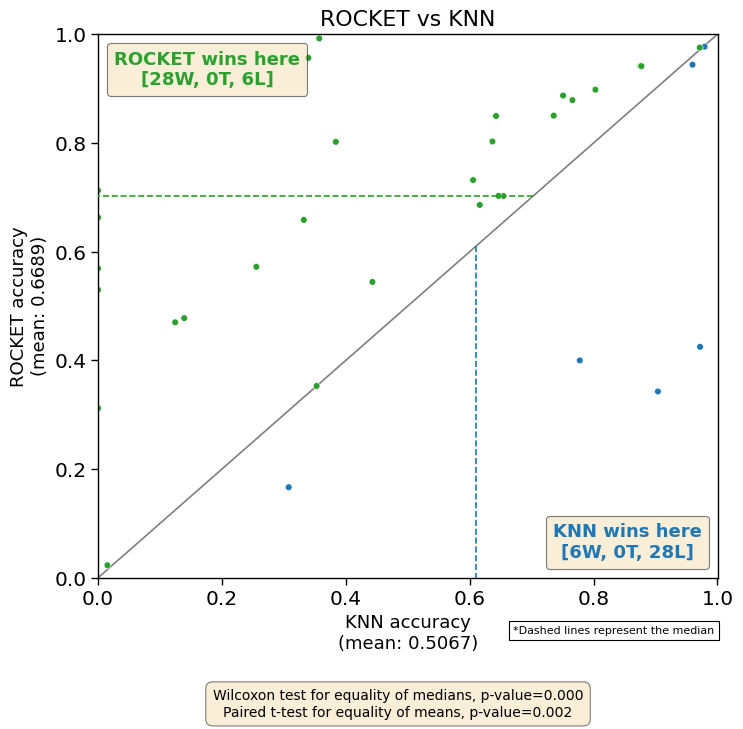

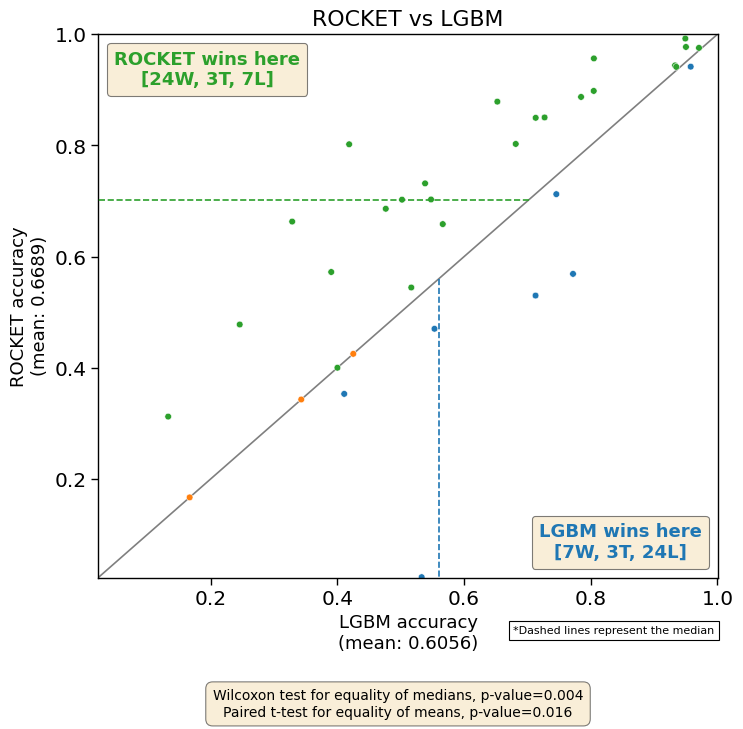

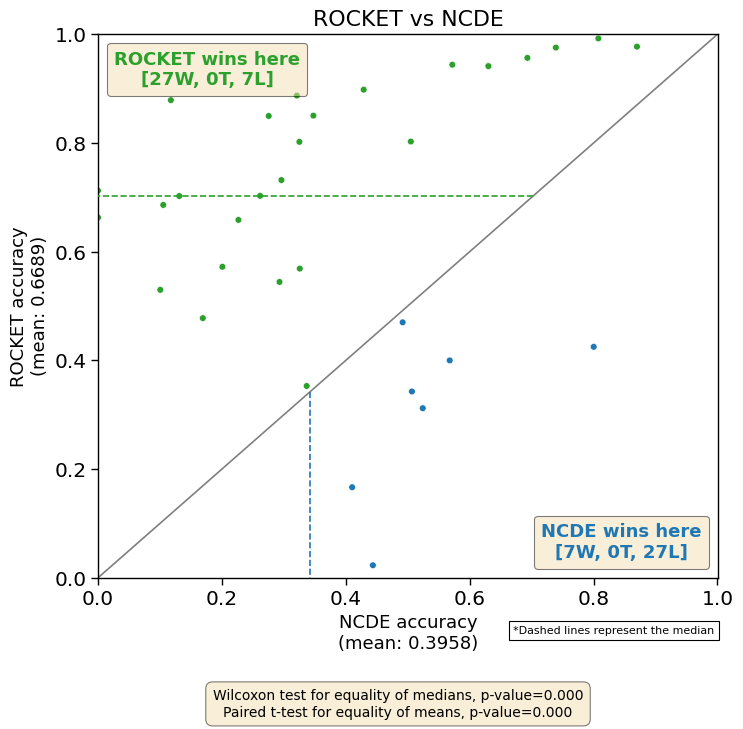

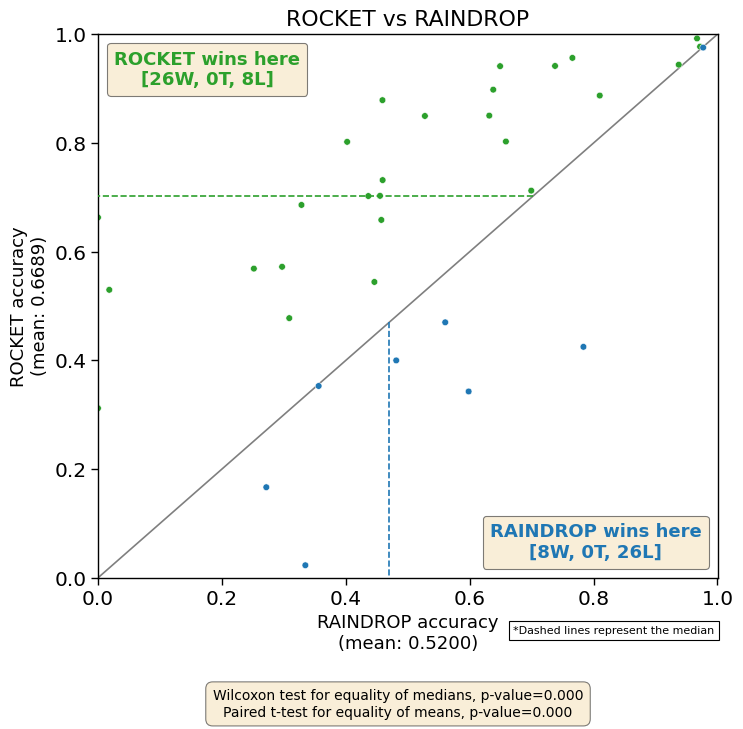

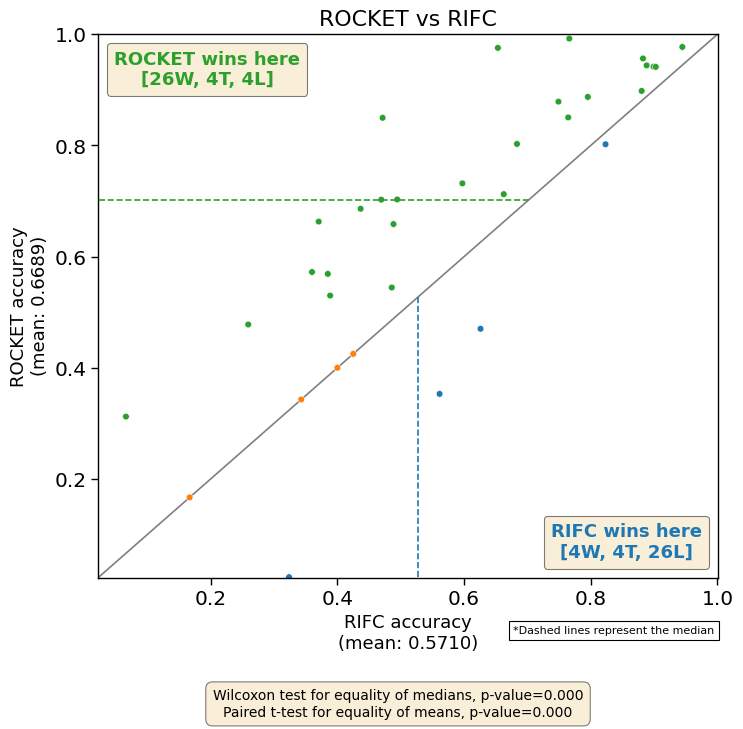

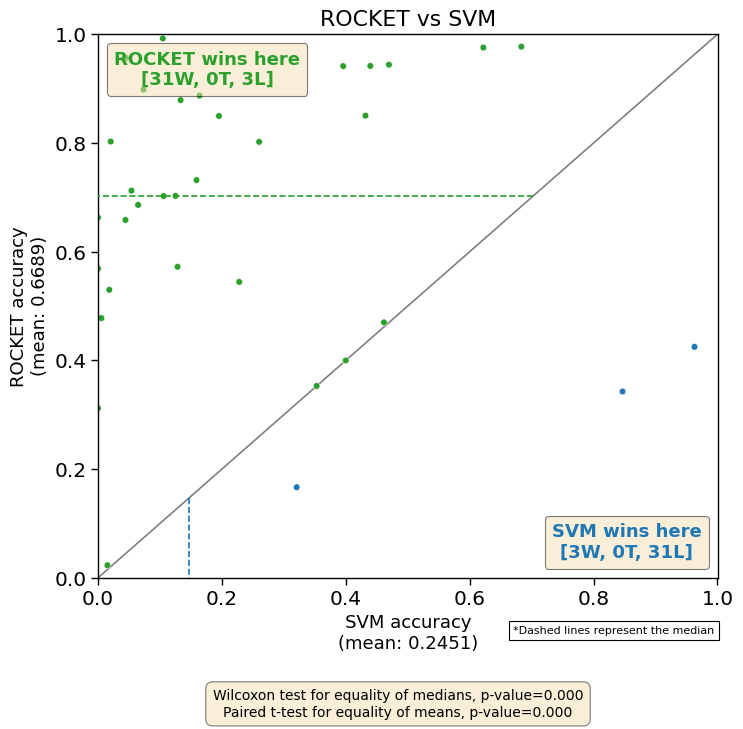

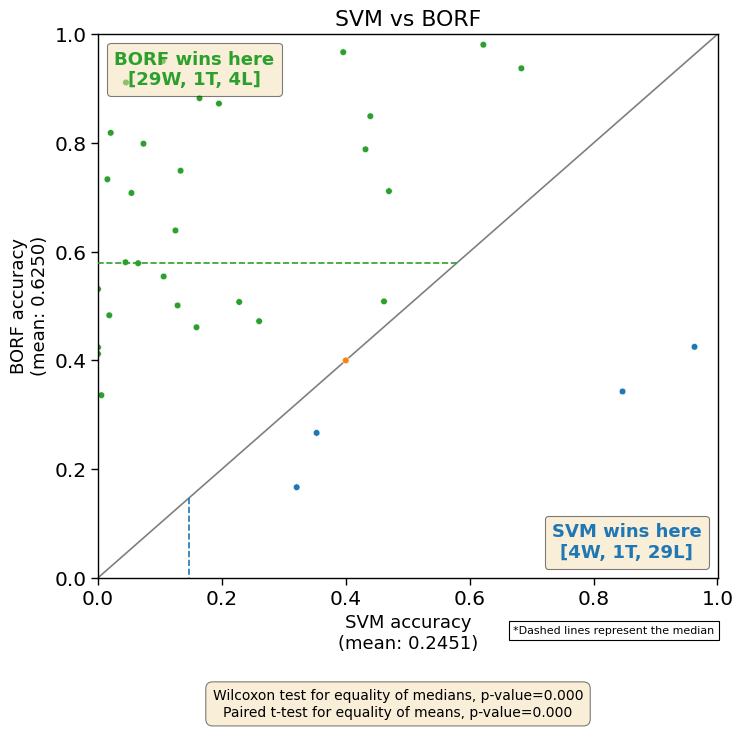

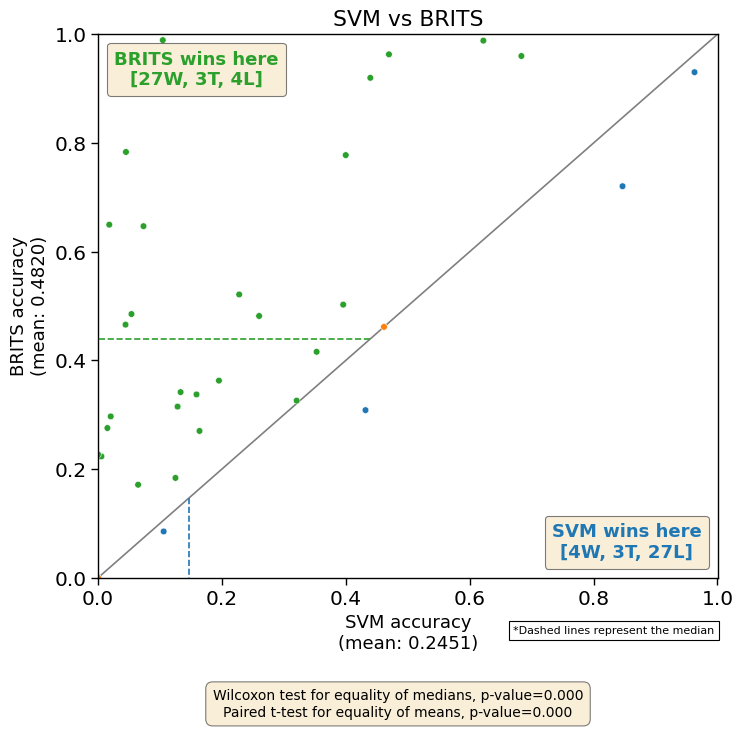

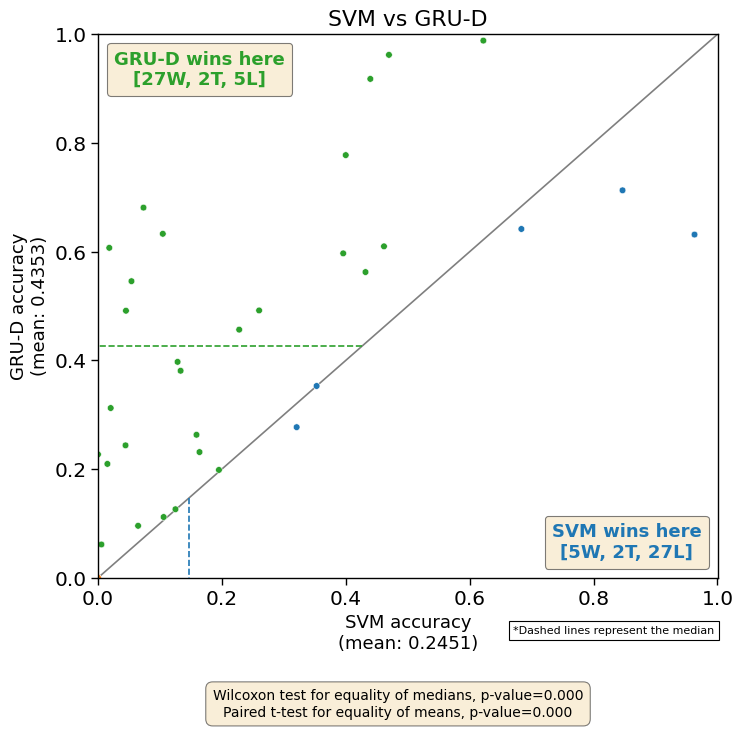

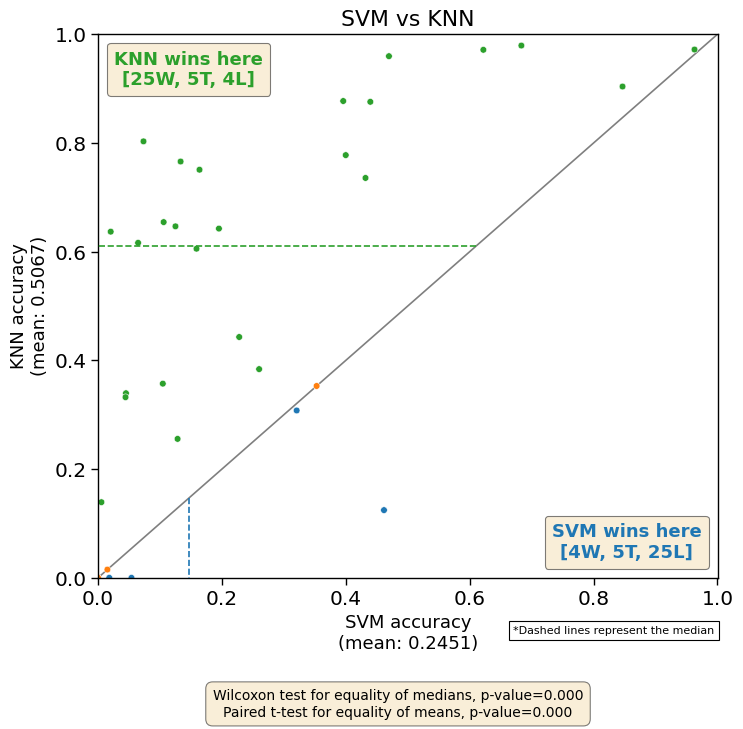

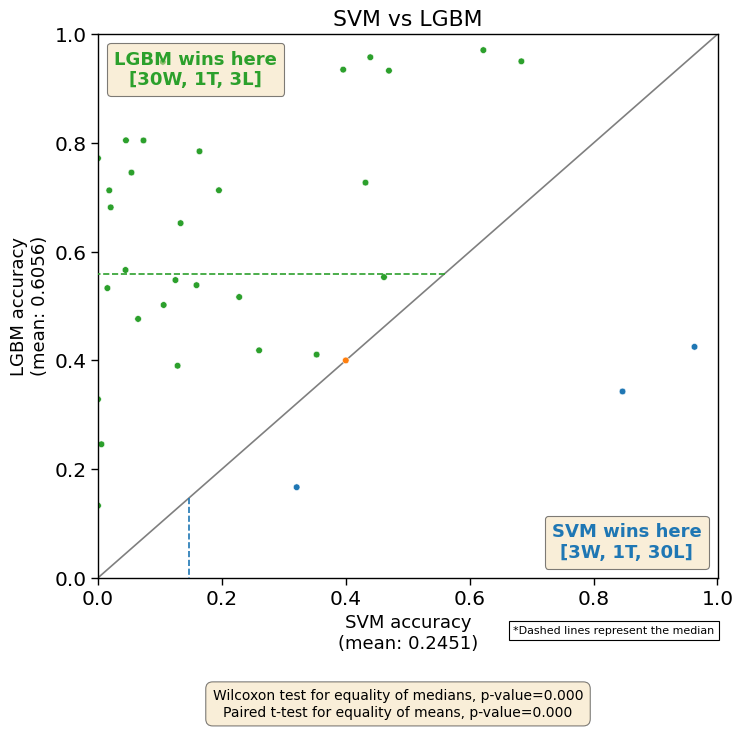

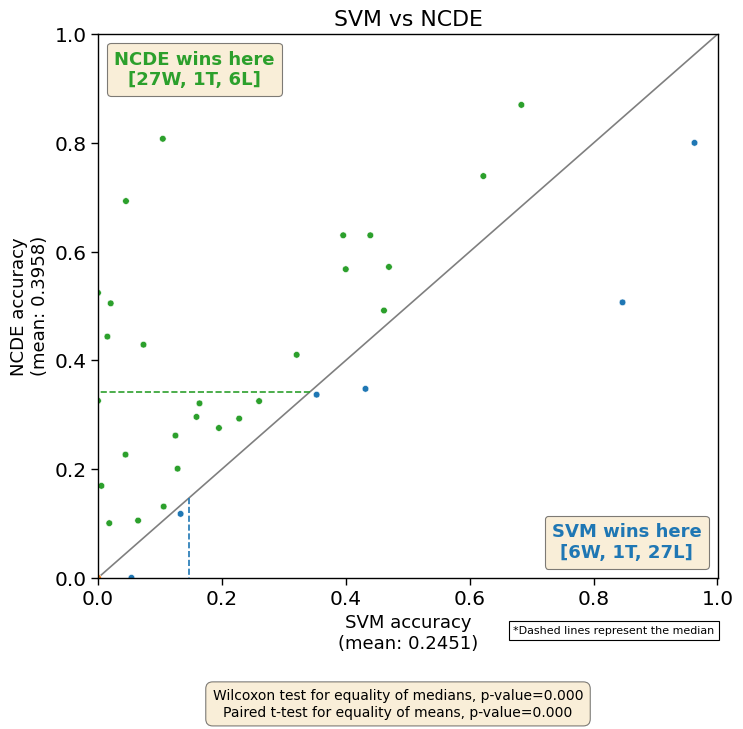

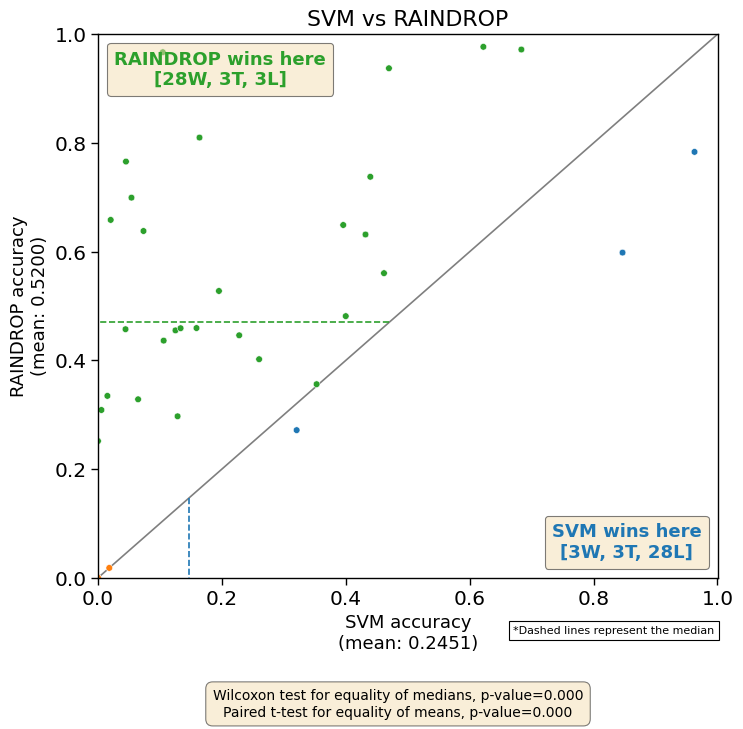

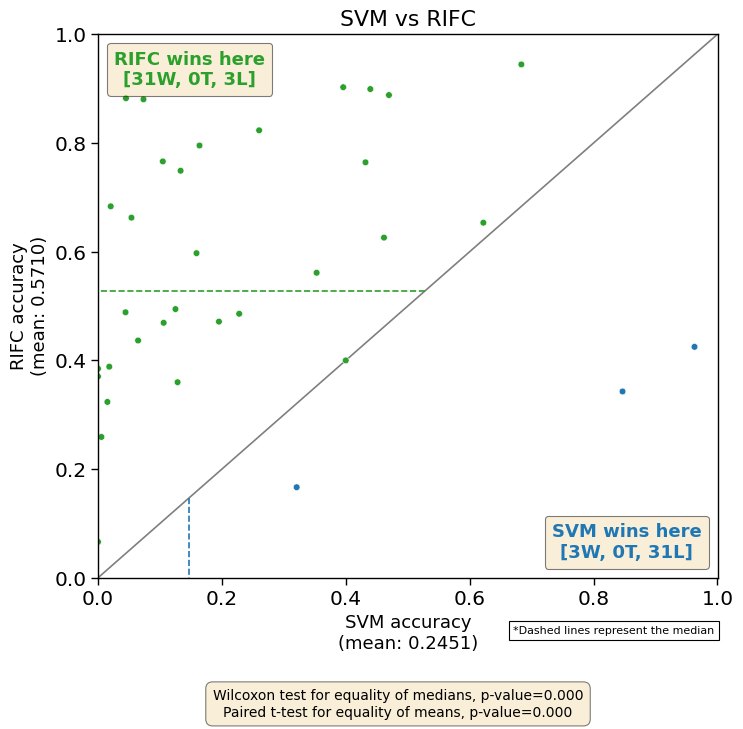

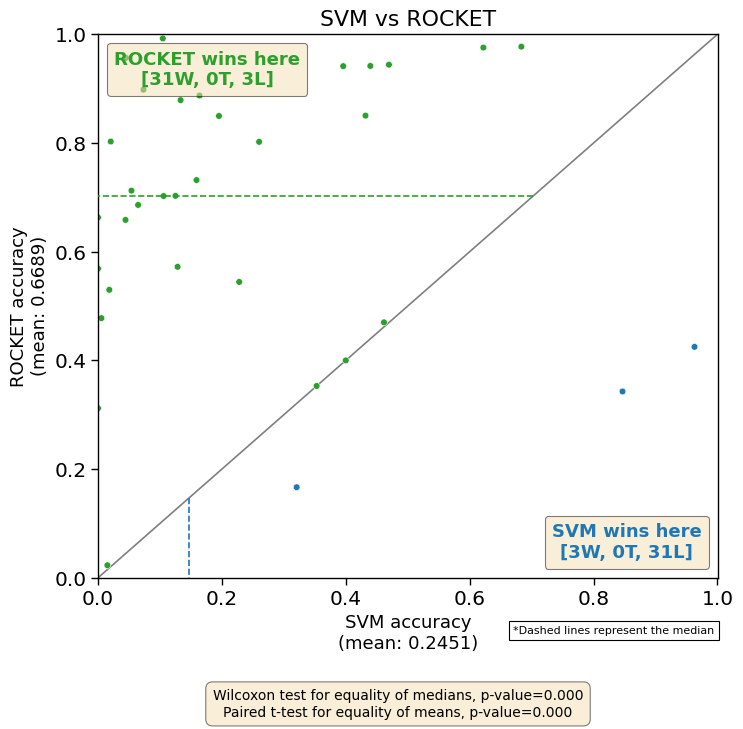

In [39]:
for method_a in df_metric.columns:
    for method_b in df_metric.columns:
        if method_a == method_b:
            continue
        plot_pairwise_scatter(df_metric.fillna(0)[method_a].values, df_metric.fillna(0)[method_b].values, method_a=method_a, method_b=method_b)
        plt.title(f"{method_a} vs {method_b}")

In [40]:
# metric = "total_time"
# df = get_runs("spinland", "iclm_01_time_not_channel")
# DEFAULTS = dict()
# model_columns = ["overrides.model"]
# df["model_str"] = ["" for _ in range(df.shape[0])]
# for column in model_columns:
#     df["model_str"] += df[column].astype(str) + "_"
# df = df[["overrides.dataset", "model_str", metric]]
# df.shape
# model_columns
# df_metric = df.pivot_table(index='overrides.dataset', columns="model_str", values=metric, dropna=True)
# df_metric.shape

In [41]:
# df_metric.mean(axis=1).sort_values().index